# Methodology Chapter Figures

This notebook builds the five figures referenced in the methodology chapter draft
(`documentation/august_draft/4_Chapter_methodology/g_methodology_2026-08-15_clean_all_applied.tex`):

1. `fig:pipeline-overview` -- overall pipeline flowchart (schematic)
2. `fig:splits-combined` -- 3-panel figure: plot-level leakage, spatial-block split with buffer, temporal split
3. `fig:age-linearity` -- training-partition age distribution with fitted Chapman-Richards curve
4. `fig:model-architecture` -- shared DNN/PINN architecture block diagram (schematic)
5. `fig:rq3-attribution` -- RQ3 target construction and attribution models, including the GNNWR mechanism (schematic)

Like `notebooks/spatial_analysis/spatial_temporal_split_visualisation.ipynb`, this notebook does not
reimplement any modelling logic -- data-driven panels (2 and 3) import the real split functions
(`models/common/splits.py`) and the real Chapman-Richards fit (`models/chapman_richards/chapman_richards.py`)
used by the model scripts, so what is plotted is exactly what those scripts do. The two purely
schematic figures (1 and 4) and the mechanism part of figure 5 have no underlying dataset to plot --
they are box-and-arrow diagrams built directly from the figure captions already written in the
chapter, so their content matches the (already-approved) caption text exactly.

Figures are displayed inline only for now -- nothing is written to disk automatically while
we iterate. `FIGURES_DIR` (set up below) is where a finished figure would eventually be saved
with `plt.savefig(FIGURES_DIR / "<name>.png")`, once a given figure is ready.

**Colour choice**: all figures use a small, fixed, colourblind-safe categorical palette (never more
than 4-5 colours, assigned to the same meaning in every figure) rather than a default matplotlib
cycle, following this project's `dataviz` skill guidance (categorical hues assigned by identity, in a
fixed order, never cycled or reused for a different meaning).

In [1]:
# Purpose: Make the models/ package importable from this notebook, the same way
# notebooks/spatial_analysis/spatial_temporal_split_visualisation.ipynb does it.
# Key logic: walk upward from this notebook's folder until a folder containing
# both README.md and data/ is found -- that folder is the project root.

import sys
from pathlib import Path

notebook_directory = Path.cwd().resolve()
project_root = next(
    folder for folder in [notebook_directory, *notebook_directory.parents]
    if (folder / "README.md").exists() and (folder / "data").exists()
)

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

# All figures are saved here, as PNGs ready for \includegraphics in the chapter.
FIGURES_DIR = project_root / "documentation" / "august_draft" / "4_Chapter_methodology" / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print("project_root:", project_root)
print("figures will be saved to:", FIGURES_DIR)

project_root: /Users/shreeyagorasia/UoE_Docs/Dissertation/forest_diss
figures will be saved to: /Users/shreeyagorasia/UoE_Docs/Dissertation/forest_diss/documentation/august_draft/4_Chapter_methodology/figures


In [2]:
import json

import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.patches import FancyArrowPatch, FancyBboxPatch, Rectangle
from matplotlib.ticker import FuncFormatter

# Figures are for a printed PDF (no hover/interactivity), so this notebook keeps to the
# print-relevant parts of the dataviz skill: a fixed, colourblind-safe categorical palette,
# thin marks, one axis per panel (no dual-axis charts), and selective direct labels instead
# of a legend wherever a direct label fits.
plt.rcParams["figure.dpi"] = 150
plt.rcParams["savefig.dpi"] = 300
plt.rcParams["savefig.bbox"] = "tight"
plt.rcParams["font.size"] = 10
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

# A small, fixed categorical palette (Okabe-Ito, a standard colourblind-safe set), with each
# colour assigned to ONE fixed meaning below and reused with that same meaning in every figure
# in this notebook -- never cycled, never repurposed for a different category.
COLOR_TRAIN = "#0072B2"      # blue
COLOR_VAL = "#E69F00"        # orange
COLOR_TEST = "#009E73"       # green
COLOR_BUFFER = "#999999"     # neutral grey -- excluded/removed rows
COLOR_CURVE = "#D55E00"      # vermillion -- fitted model / analytical curve
COLOR_NEUTRAL_BOX = "#F0F0F0"  # schematic-diagram box fill
COLOR_NEUTRAL_EDGE = "#555555"  # schematic-diagram box edge
COLOR_EXAMPLE_4SURVEY = "#CC79A7"  # reddish purple -- individual 4survey example plots (age-linearity figure only)
COLOR_EXAMPLE_6SURVEY = "#56B4E9"  # sky blue -- individual 6survey example plots (age-linearity figure only)


def lighten_color(hex_color, blend_toward_white):
    # Mixes hex_color with white -- e.g. blend_toward_white=0.7 gives a colour that is 70%
    # of the way to white, a much softer/lighter tint than lowering alpha would give (alpha
    # blending can look muddy once it overlaps a line or another shaded region; a flat
    # lighter colour stays clean no matter what it sits on top of).
    original_rgb = np.array(mcolors.to_rgb(hex_color))
    white_rgb = np.array([1.0, 1.0, 1.0])
    lightened_rgb = original_rgb + (white_rgb - original_rgb) * blend_toward_white
    return tuple(lightened_rgb)


print("Setup complete.")

Setup complete.


## Figure: `fig:age-linearity`

**Chapter spec (from the LaTeX comment above the placeholder):** training-partition age
distribution as a histogram (4survey cohort), with the observed age range shown against a single
fitted Chapman-Richards curve (Equation `eq:cr`) over the same age range, to show visually that the
observed section of the curve sits on its near-linear early-to-mid segment -- the reason a plain
linear regression baseline is defensible despite the true age-height relationship being nonlinear.

**Data/model used:** the real training partition is reconstructed exactly as
`models/baselines/run_baselines.py` builds it (`filter_data(maturity_age_min=30)` then the primary
`spatial_block_split`, train rows only), and the overlaid curve is the *already-fitted* curve saved to
`outputs/chapman_richards/4survey/params.json` (not refit here), so the curve shown is exactly the one
actually used as the PINN's physics anchor.

In [3]:
from models.chapman_richards.chapman_richards import chapman_richards
from models.common.data import filter_data, load_cohort_data
from models.common.geo import load_plot_coordinates
from models.common.splits import spatial_block_split

COHORT = "4survey"  # primary cohort throughout the chapter
AGE_COL = "Age"
HEIGHT_COL = "elev_percentile_95th"
SPATIAL_BUFFER_METRES = 60
SPLIT_SEED = 42

# Step 1: load the same columns run_baselines.py loads, apply the same maturity filter.
raw_table = load_cohort_data(COHORT)
filtered_table = filter_data(raw_table, maturity_age_min=30)

# Step 2: apply the exact same primary spatial-block split (whole compartments, 60m buffer,
# seed 42) that produces the training partition the real Chapman-Richards curve was fit on.
coordinates_df = load_plot_coordinates()
filtered_table = filtered_table.copy()
filtered_table["split"] = spatial_block_split(
    filtered_table, block_col="cpmt", buffer_distance=SPATIAL_BUFFER_METRES,
    coordinates_df=coordinates_df, seed=SPLIT_SEED,
)
train_df = filtered_table[filtered_table["split"] == "train"]

print(f"{COHORT}: {len(train_df):,} training rows after maturity filter + spatial-block split")
print(f"Training age range: {train_df[AGE_COL].min():.0f} to {train_df[AGE_COL].max():.0f} years")

# Step 3: load the already-fitted Chapman-Richards curve for this cohort (not refit here).
with open(project_root / "outputs" / "chapman_richards" / COHORT / "params.json") as f:
    cr_params = json.load(f)
print("Loaded fitted CR params:", cr_params)

def is_monotonic_trajectory(plot_rows_sorted_by_age):
    # The Chapman-Richards curve assumes a single monotonic growth trajectory per plot; the
    # chapter text itself says a plot whose real trajectory is non-monotonic (e.g. following
    # disturbance) is "not represented by this functional form ... handled by the outlier
    # audit ... rather than by the curve itself". So example plots picked for THIS figure
    # need the same check, or a disturbed/anomalous plot (height dropping between two real
    # surveys -- confirmed to happen in this raw data, e.g. plot 351168: 7.2m in 2008 down to
    # 3.1m in 2012) could get shown as if it were a normal "less productive" example.
    heights = plot_rows_sorted_by_age[HEIGHT_COL].to_numpy()
    return np.all(np.diff(heights) >= 0)


def pick_example_plots(cohort_name, above_target_percentiles, below_target_percentiles):
    # Picks real individual plots to draw as example trajectories alongside the population
    # curve: only plots with a FULL survey record for their cohort AND a monotonic real
    # trajectory are eligible (so each example line spans the whole age range and is a
    # genuine growth curve, not a data artefact). Plots are then picked by TARGETING a given
    # percentile of the residual distribution (e.g. the plot closest to the 80th percentile),
    # rather than taking the single most extreme plot in the whole cohort -- the most
    # extreme residual in a population this size is a wild outlier (an early version of this
    # picked a +31m residual plot), which does not look "close to the curve" at all and
    # defeats the point of showing a representative example. Targeting a moderate percentile
    # gives a plot that is genuinely above/below the curve without being a freak case.
    cohort_raw = load_cohort_data(cohort_name)
    rows_per_plot = cohort_raw.groupby("identification").size()
    full_record_length = rows_per_plot.max()
    full_record_plot_ids = rows_per_plot[rows_per_plot == full_record_length].index

    cohort_full = cohort_raw[cohort_raw["identification"].isin(full_record_plot_ids)].copy()

    monotonic_plot_ids = [
        plot_id for plot_id, plot_rows in cohort_full.groupby("identification")
        if is_monotonic_trajectory(plot_rows.sort_values(AGE_COL))
    ]
    n_dropped = len(full_record_plot_ids) - len(monotonic_plot_ids)
    print(f"{cohort_name}: dropped {n_dropped} of {len(full_record_plot_ids)} full-record plots for a non-monotonic (disturbed) trajectory")
    cohort_full = cohort_full[cohort_full["identification"].isin(monotonic_plot_ids)]

    predicted_height = chapman_richards(cohort_full[AGE_COL], cr_params["y_max"], cr_params["k"], cr_params["p"])
    cohort_full["residual"] = cohort_full[HEIGHT_COL] - predicted_height

    mean_residual_per_plot = cohort_full.groupby("identification")["residual"].mean()

    chosen_ids = []
    for target_percentile in above_target_percentiles + below_target_percentiles:
        target_value = np.percentile(mean_residual_per_plot.to_numpy(), target_percentile)
        # Closest plot to that percentile's residual VALUE, excluding plots already chosen.
        remaining = mean_residual_per_plot.drop(index=chosen_ids, errors="ignore")
        closest_plot_id = (remaining - target_value).abs().idxmin()
        chosen_ids.append(closest_plot_id)
        print(
            f"  {cohort_name} target percentile {target_percentile}: plot {closest_plot_id}, "
            f"mean residual {mean_residual_per_plot[closest_plot_id]:+.1f} m"
        )

    chosen_df = cohort_full[cohort_full["identification"].isin(chosen_ids)]
    return {plot_id: chosen_df[chosen_df["identification"] == plot_id].sort_values(AGE_COL) for plot_id in chosen_ids}


# Target moderate percentiles of the residual distribution, not the single most extreme
# plot -- e.g. "70th percentile" means a plot that is above the curve by roughly as much as
# 70% of plots are below it, a real but not freakish example.
four_survey_examples = pick_example_plots("4survey", above_target_percentiles=[70, 90], below_target_percentiles=[15])
six_survey_examples = pick_example_plots("6survey", above_target_percentiles=[80], below_target_percentiles=[20])

print("4survey example plot ids:", list(four_survey_examples.keys()))
print("6survey example plot ids:", list(six_survey_examples.keys()))

  Rows before filtering: 287,064
  Removed by Age < 30 at the 2023 survey (whole plot dropped): 54,616 rows
  Removed by yield class between 2 and 50 (whole plot dropped): 0 rows
  Rows after filtering: 232,448
  Buffer: 2,186 train plots are within 60 m of a val/test plot and are excluded ('buffer'). val/test plots are never removed.
4survey: 129,672 training rows after maturity filter + spatial-block split
Training age range: 15 to 94 years
Loaded fitted CR params: {'y_max': 51.96307116000001, 'k': 0.010287895198776128, 'p': 0.8648990817686512, 'cohort': '4survey', 'n_rows_fit': 139472, 'fit_date': '2026-08-09T22:51:44.508825+00:00'}
4survey: dropped 7645 of 71766 full-record plots for a non-monotonic (disturbed) trajectory
  4survey target percentile 70: plot 21280, mean residual +3.2 m
  4survey target percentile 90: plot 110963, mean residual +6.4 m
  4survey target percentile 15: plot 127402, mean residual -5.1 m
6survey: dropped 1833 of 13897 full-record plots for a non-monotoni

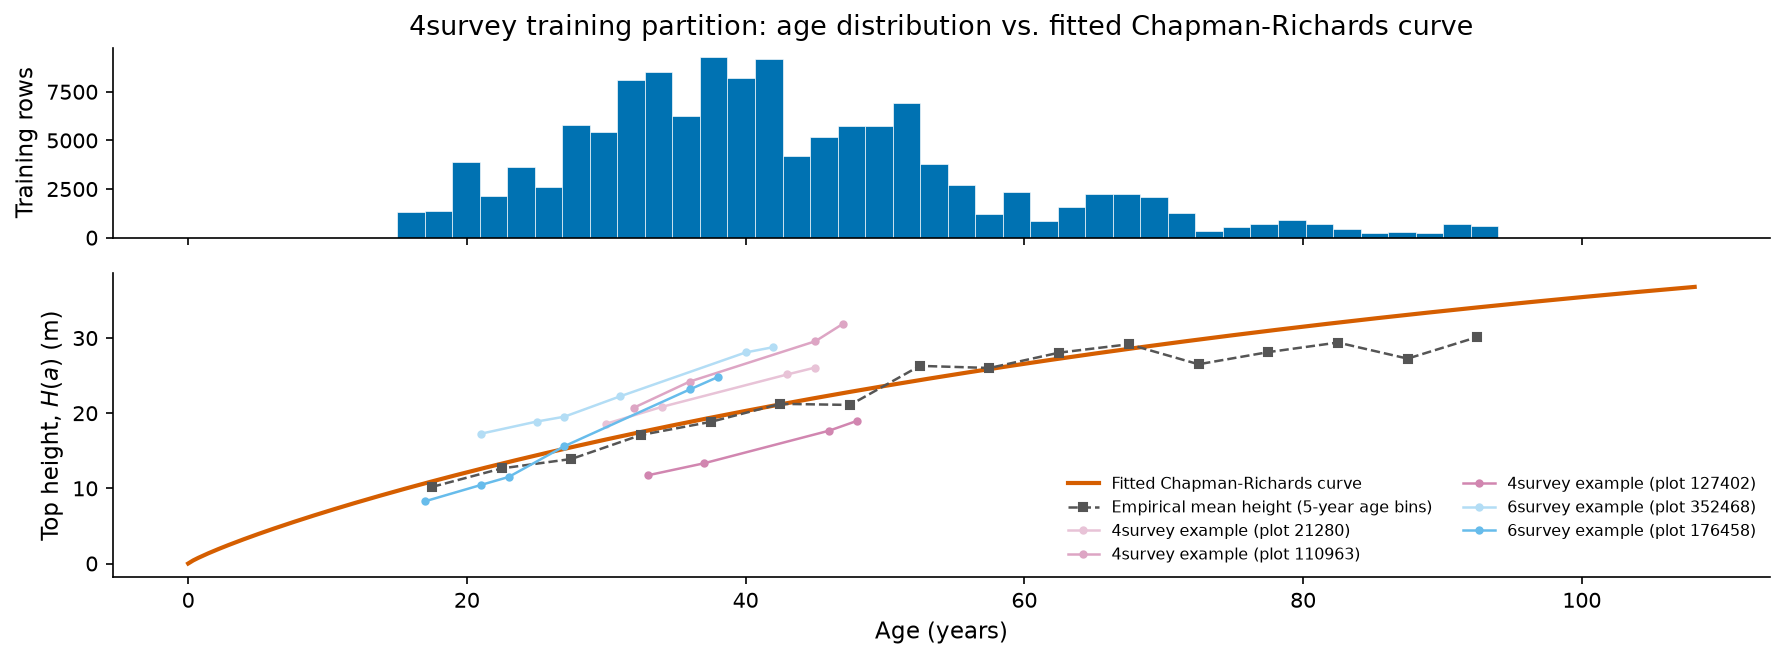

In [4]:
# Two panels stacked on a shared x-axis (age), rather than one panel with two y-axes
# (counts vs. metres) -- a dual-axis chart with two different y-scales is misleading (see the
# dataviz skill's anti-patterns), so a shared x-axis with two honestly-scaled panels is used
# instead. Wide and short (rather than the previous tall, roughly-square layout), to match
# how this figure actually sits on a document page.
fig, (ax_hist, ax_curve) = plt.subplots(
    2, 1, figsize=(12, 4.5), sharex=True, gridspec_kw={"height_ratios": [1, 1.6]},
)

# --- Top panel: age histogram of the training partition ---
ax_hist.hist(train_df[AGE_COL], bins=40, color=COLOR_TRAIN, edgecolor="white", linewidth=0.3)
ax_hist.set_ylabel("Training rows", fontsize=11)
ax_hist.set_title(f"{COHORT} training partition: age distribution vs. fitted Chapman-Richards curve", fontsize=13)
ax_hist.tick_params(labelsize=10)

age_min_observed = train_df[AGE_COL].min()
age_max_observed = train_df[AGE_COL].max()

# Curve is drawn from age 0 so the reader can see the full sigmoid shape, not just the
# observed slice.
age_full_range = np.linspace(0, age_max_observed * 1.15, 300)
height_full_range = chapman_richards(age_full_range, cr_params["y_max"], cr_params["k"], cr_params["p"])
ax_curve.plot(age_full_range, height_full_range, color=COLOR_CURVE, linewidth=2, label="Fitted Chapman-Richards curve")

# Empirical mean height per 5-year age band, computed directly from the same training
# partition as the histogram above -- lets the reader see how closely the fitted curve
# actually tracks the raw data's own average, rather than just asserting it does.
age_bin_width = 5
train_df["_age_bin"] = (train_df[AGE_COL] // age_bin_width) * age_bin_width
binned_mean_height = train_df.groupby("_age_bin")[HEIGHT_COL].mean()
ax_curve.plot(
    binned_mean_height.index + age_bin_width / 2, binned_mean_height.values,
    color=COLOR_NEUTRAL_EDGE, marker="s", markersize=4, linewidth=1.2, linestyle="--",
    label=f"Empirical mean height ({age_bin_width}-year age bins)",
)

# Overlay the real example plots' actual (age, height) trajectories -- a light shade per
# plot within each cohort's own colour family (COLOR_EXAMPLE_4SURVEY / COLOR_EXAMPLE_6SURVEY),
# distinct from the curve (vermillion) and the empirical mean (grey dashed). Each example is
# a REAL plot's own data, not a synthetic curve, so it is drawn as markers connected by a
# thin line rather than a smooth curve.
example_groups = [
    (four_survey_examples, COLOR_EXAMPLE_4SURVEY, "4survey"),
    (six_survey_examples, COLOR_EXAMPLE_6SURVEY, "6survey"),
]
for examples_dict, base_color, cohort_label in example_groups:
    # Blend fractions spread the lines from a fairly light shade to a slightly darker one, so
    # multiple examples from the same cohort are distinguishable from each other while all
    # staying visually secondary to the bold, un-blended average curve.
    blend_fractions = np.linspace(0.55, 0.1, len(examples_dict))
    for (plot_id, plot_df), blend in zip(examples_dict.items(), blend_fractions):
        ax_curve.plot(
            plot_df[AGE_COL], plot_df[HEIGHT_COL],
            color=lighten_color(base_color, blend), marker="o", markersize=3, linewidth=1.2,
            label=f"{cohort_label} example (plot {plot_id})",
        )

ax_curve.set_xlabel("Age (years)", fontsize=11)
ax_curve.set_ylabel("Top height, $H(a)$ (m)", fontsize=11)
ax_curve.tick_params(labelsize=10)
ax_curve.legend(loc="lower right", frameon=False, fontsize=7.5, ncol=2)

plt.tight_layout()
plt.show()

## Figure: Chapman-Richards growth curve (background-chapter version, no age histogram)

Same curve, empirical mean-height overlay, and example plot trajectories as the methodology
chapter's age-linearity figure above, but without a separate histogram panel -- for introducing
the Chapman-Richards curve itself in the background chapter, where the training-partition framing
doesn't apply. Reuses `train_df`, `cr_params`, and the example plots already computed above
rather than recomputing anything.

Age distribution is now shown as a very light backdrop on a second, unlabelled y-axis (context
only, not meant to be read precisely -- a real second y-axis with its own tick labels would be
the dual-axis anti-pattern the `dataviz` skill warns against), the empirical mean-age line sits
behind the fitted curve, the minimum observed age is annotated with why it exists (not a filter --
the earliest survey already found no younger plots), and the fitted $y_{\max}, k, p$ values are
shown directly on the curve.

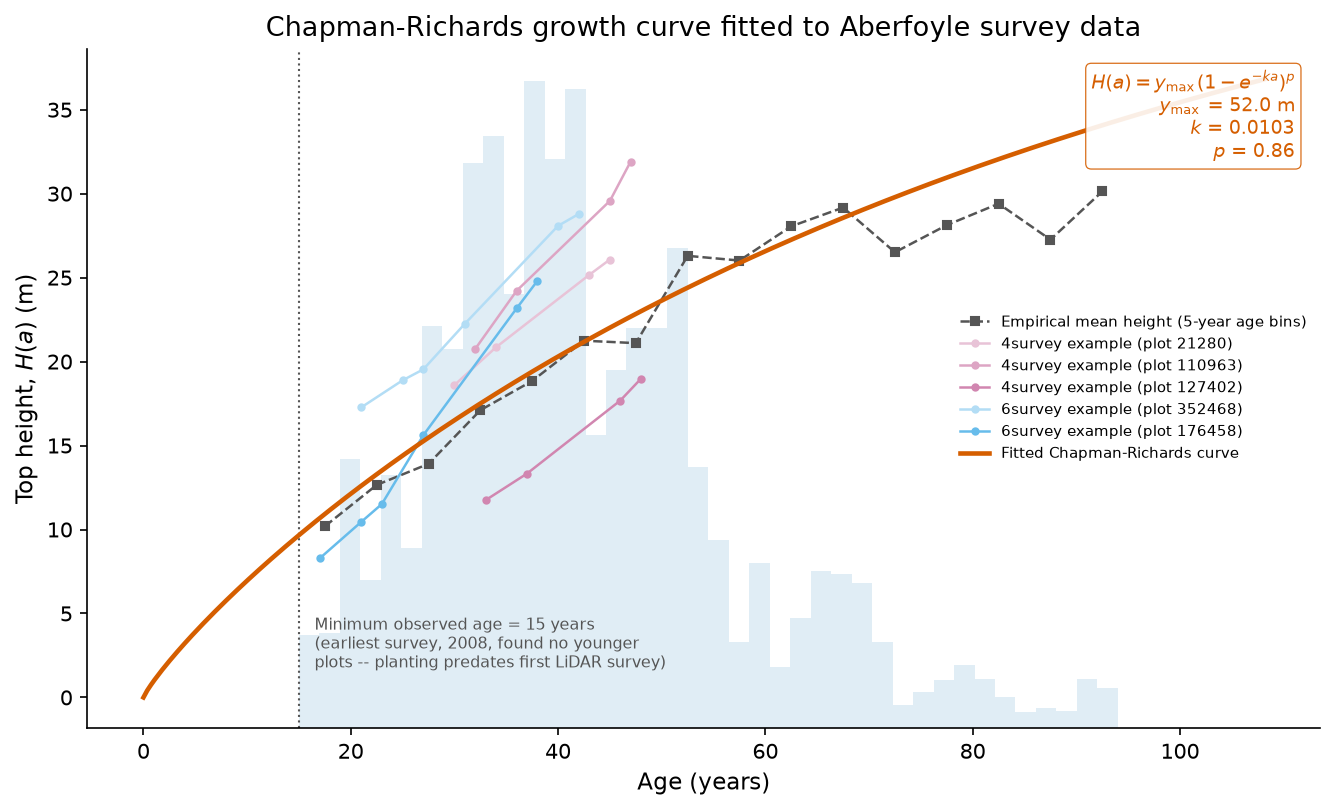

In [5]:
fig, ax_curve_only = plt.subplots(figsize=(9, 5.5))

# Age-distribution backdrop, on its own y-axis so it does not compete with the height axis for
# scale -- very low alpha and no ticks/label, since it is context (where does the data actually
# sit) rather than a value meant to be read off precisely.
ax_age_backdrop = ax_curve_only.twinx()
ax_age_backdrop.hist(train_df[AGE_COL], bins=40, color=COLOR_TRAIN, alpha=0.12, zorder=0)
ax_age_backdrop.set_yticks([])
ax_age_backdrop.set_ylabel("")
for spine in ax_age_backdrop.spines.values():
    spine.set_visible(False)

# Let the backdrop show through behind the curve panel (twinx() would otherwise stack the new
# axes' own white background on top, hiding it).
ax_curve_only.set_zorder(ax_age_backdrop.get_zorder() + 1)
ax_curve_only.patch.set_visible(False)

# Empirical mean-age line drawn BEHIND the fitted curve (lower zorder), so the curve -- the
# actual subject of this figure -- reads as the primary line.
ax_curve_only.plot(
    binned_mean_height.index + age_bin_width / 2, binned_mean_height.values,
    color=COLOR_NEUTRAL_EDGE, marker="s", markersize=4, linewidth=1.2, linestyle="--",
    label=f"Empirical mean height ({age_bin_width}-year age bins)", zorder=2,
)

for examples_dict, base_color, cohort_label in example_groups:
    blend_fractions = np.linspace(0.55, 0.1, len(examples_dict))
    for (plot_id, plot_df), blend in zip(examples_dict.items(), blend_fractions):
        ax_curve_only.plot(
            plot_df[AGE_COL], plot_df[HEIGHT_COL],
            color=lighten_color(base_color, blend), marker="o", markersize=3, linewidth=1.2,
            label=f"{cohort_label} example (plot {plot_id})", zorder=2,
        )

ax_curve_only.plot(
    age_full_range, height_full_range, color=COLOR_CURVE, linewidth=2.2,
    label="Fitted Chapman-Richards curve", zorder=3,
)

# Fitted-parameter key, directly on the curve -- the reader can see the actual equation, not
# just its shape. Placed top-right in axes-fraction coordinates (independent of the curve's
# own data values), sitting ABOVE the main legend, which is now positioned centre-right below it.
ax_curve_only.text(
    0.98, 0.97,
    f"$H(a) = y_{{\\max}}(1-e^{{-ka}})^p$\n$y_{{\\max}}$ = {cr_params['y_max']:.1f} m\n$k$ = {cr_params['k']:.4f}\n$p$ = {cr_params['p']:.2f}",
    transform=ax_curve_only.transAxes, fontsize=9, color=COLOR_CURVE, ha="right", va="top", zorder=4,
    bbox=dict(boxstyle="round", facecolor="white", edgecolor=COLOR_CURVE, linewidth=0.6, alpha=0.9),
)

# Minimum observed age, annotated with WHY it exists -- not a deliberate filter, just that the
# earliest survey (2008) never found any plot younger than this (plots were already established
# plantation age by the time LiDAR surveying began).
ax_curve_only.axvline(age_min_observed, color=COLOR_NEUTRAL_EDGE, linewidth=1, linestyle=":", zorder=1)
ax_curve_only.text(
    age_min_observed + 1.5, height_full_range.max() * 0.04,
    f"Minimum observed age = {age_min_observed:.0f} years\n(earliest survey, 2008, found no younger\nplots -- planting predates first LiDAR survey)",
    fontsize=7.5, color=COLOR_NEUTRAL_EDGE, va="bottom",
)

ax_curve_only.set_xlabel("Age (years)", fontsize=11)
ax_curve_only.set_ylabel("Top height, $H(a)$ (m)", fontsize=11)
ax_curve_only.tick_params(labelsize=10)
ax_curve_only.set_title("Chapman-Richards growth curve fitted to Aberfoyle survey data", fontsize=13)
ax_curve_only.legend(loc="center right", frameon=False, fontsize=7)

for spine in ["top", "right"]:
    ax_curve_only.spines[spine].set_visible(False)

plt.tight_layout()
plt.show()

## Figure: Chapman-Richards curves by yield class (background-chapter version)

A different, richer figure for the background chapter: one Chapman-Richards curve fit PER
YIELD CLASS (`yldc`), rather than a single pooled curve -- matching the style of
`ChapmanPlot_SS_Aberfoyle.png`. Each curve is a REAL fit on this project's own Aberfoyle
training data (reusing `fit()` from `models/chapman_richards/chapman_richards.py`, the same
function used everywhere else in this project), grouped by yield class, not a redrawn or
approximated version of the reference image.

**Colour note**: this uses a rainbow-spectrum colormap (`turbo`) to match the reference image's
own style and match the forestry-standard convention for yield-class plots. This is a deliberate
departure from this notebook's usual colourblind-safe, single-hue-sequential rule (see the
`dataviz` skill's guidance) -- worth being aware that a plain rainbow colormap is harder for
colorblind readers to order correctly than a single-hue ramp would be. Kept here because you
asked to match the reference style specifically; flag if you'd rather switch to a single-hue
sequential ramp instead.

12 yield classes found: [np.int32(2), np.int32(4), np.int32(6), np.int32(8), np.int32(10), np.int32(12), np.int32(14), np.int32(16), np.int32(18), np.int32(20), np.int32(22), np.int32(24)]
  yldc=2: n=396 rows, y_max=31.9, k=0.0178, p=1.88
  yldc=4: n=2,800 rows, y_max=197.6, k=0.0020, p=1.11
  yldc=6: n=2,284 rows, y_max=42.4, k=0.0217, p=2.45
  yldc=8: n=4,576 rows, y_max=52.0, k=0.0087, p=0.88
  yldc=10: n=6,848 rows, y_max=44.5, k=0.0168, p=1.37
  yldc=12: n=24,432 rows, y_max=50.2, k=0.0115, p=1.11
  yldc=14: n=17,352 rows, y_max=44.9, k=0.0157, p=1.01
  yldc=16: n=11,460 rows, y_max=235.7, k=0.0009, p=0.74
  yldc=18: n=20,868 rows, y_max=78.4, k=0.0079, p=1.08
  yldc=20: n=14,752 rows, y_max=48.8, k=0.0195, p=1.18
  yldc=22: n=3,504 rows, y_max=41.8, k=0.0304, p=1.44
  yldc=24: n=20,400 rows, y_max=44.4, k=0.0259, p=1.27


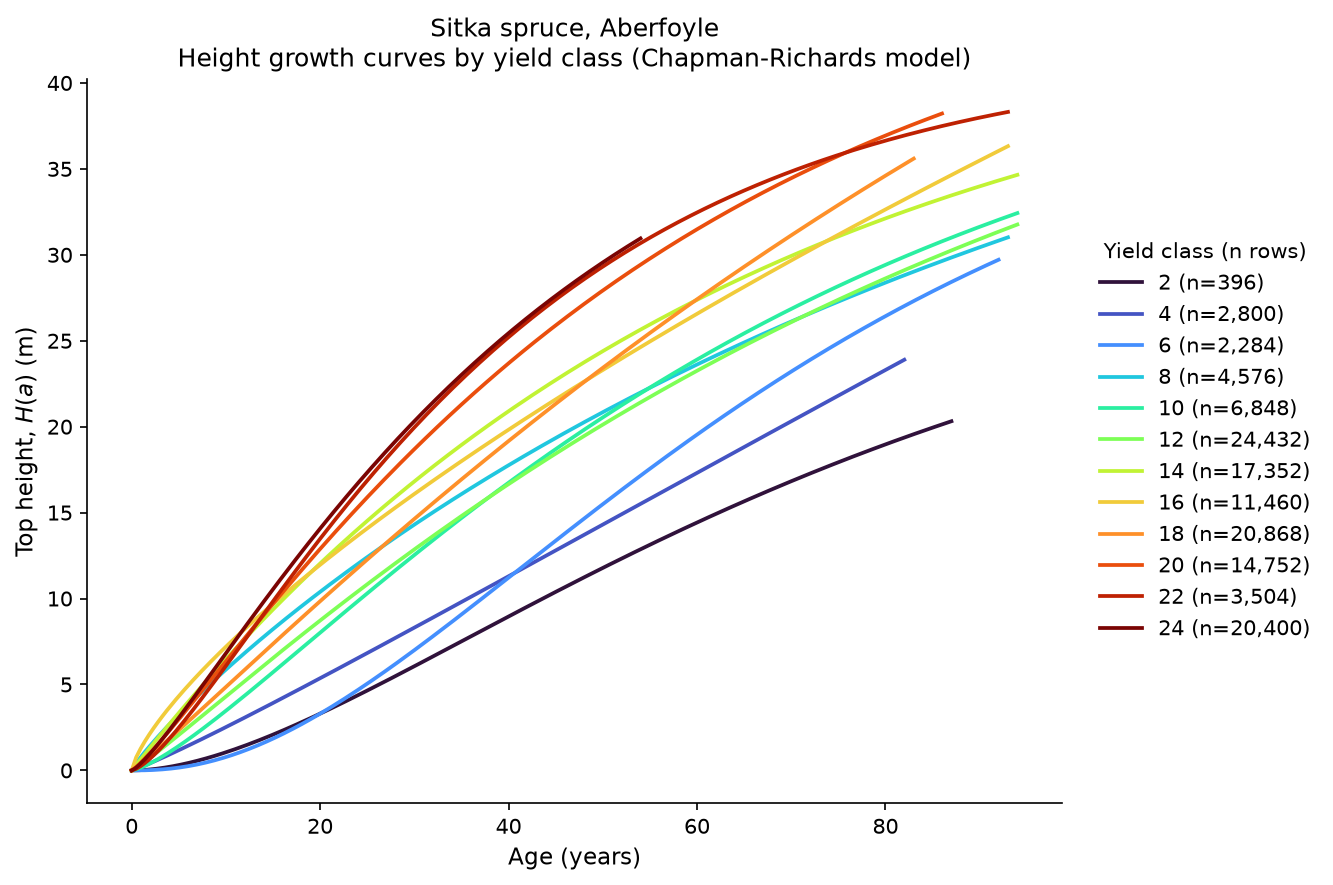

In [6]:
from models.chapman_richards.chapman_richards import fit as fit_chapman_richards

yield_classes = sorted(train_df["yldc"].dropna().unique())
print(f"{len(yield_classes)} yield classes found: {yield_classes}")

yield_class_curves = {}
for yldc_value in yield_classes:
    yldc_rows = train_df[train_df["yldc"] == yldc_value]
    try:
        yldc_params = fit_chapman_richards(yldc_rows, age_col=AGE_COL, height_col=HEIGHT_COL)
        yield_class_curves[yldc_value] = {"params": yldc_params, "n_rows": len(yldc_rows), "max_age": yldc_rows[AGE_COL].max()}
        print(f"  yldc={yldc_value:.0f}: n={len(yldc_rows):,} rows, y_max={yldc_params['y_max']:.1f}, k={yldc_params['k']:.4f}, p={yldc_params['p']:.2f}")
    except RuntimeError as error:
        print(f"  yldc={yldc_value:.0f}: fit did not converge ({error}), skipped")

# Rainbow colormap, one colour per yield class, ordered low to high -- matches the reference
# image's own convention (see the colour note above for the colourblind-safety trade-off).
cmap = plt.colormaps["turbo"]
yldc_colors = {yldc_value: cmap(i / max(len(yield_class_curves) - 1, 1)) for i, yldc_value in enumerate(yield_class_curves)}

fig, ax_yldc = plt.subplots(figsize=(9, 6))
for yldc_value, curve_info in yield_class_curves.items():
    age_range = np.linspace(0, curve_info["max_age"], 200)
    predicted_height = chapman_richards(age_range, curve_info["params"]["y_max"], curve_info["params"]["k"], curve_info["params"]["p"])
    ax_yldc.plot(
        age_range, predicted_height, color=yldc_colors[yldc_value], linewidth=1.8,
        label=f"{yldc_value:.0f} (n={curve_info['n_rows']:,})",
    )

ax_yldc.set_xlabel("Age (years)", fontsize=11)
ax_yldc.set_ylabel("Top height, $H(a)$ (m)", fontsize=11)
ax_yldc.tick_params(labelsize=10)
ax_yldc.set_title("Sitka spruce, Aberfoyle\nHeight growth curves by yield class (Chapman-Richards model)", fontsize=12)
ax_yldc.legend(title="Yield class (n rows)", loc="center left", bbox_to_anchor=(1.02, 0.5), fontsize=10, frameon=False)

for spine in ["top", "right"]:
    ax_yldc.spines[spine].set_visible(False)

plt.tight_layout()
plt.show()

## Figure: `fig:splits-combined`

**Chapter spec:** a combined 3-panel figure.
- **Panel A** -- plot-level split: nearest-neighbour leakage, with a distance callout.
- **Panel B** -- spatial-block split: whole compartments held out, with the 60m buffer ring shown.
- **Panel C** -- temporal split: timeline with the 2012-2021 survey gap marked.

This reuses the exact split functions from `models/common/splits.py`, following the same pattern as
`notebooks/spatial_analysis/spatial_temporal_split_visualisation.ipynb` (which already has working
code for panels A and B individually -- this section adapts that code into one combined figure with
a temporal panel added, rather than three separate figures).

**Note on the "reuse the Data chapter's `fig:data-cohort-map` base layer" instruction in the chapter
comment:** that Data-chapter figure does not exist yet either (its own `.tex` file still shows a plain
`MAP PLACEHOLDER`, with no notebook or script producing it found in this repository). So the map
styling below is written as a small reusable function (`plot_split_map`, next cell) that the Data
chapter's own figure can call later for visual consistency, rather than pointing at a base layer that
does not exist yet.

In [7]:
from models.common.geo import find_train_plots_near_holdout
from models.common.splits import plot_level_split, temporal_split

# Panels A and B are 4survey only (the primary cohort, same as every other figure in this
# notebook); Panel C (temporal split) shows BOTH cohorts, since 4survey and 6survey have
# different training years and that difference is the point of the panel.
COHORT_FOR_SPLITS = "4survey"

# Reload the raw (row-per-survey) master table for this cohort, joined to plot coordinates --
# splits are usually shown at plot level (one point per plot), matching the existing
# spatial_temporal_split_visualisation.ipynb convention.
master_path = project_root / "data" / "processed" / "master" / f"clean_master_{COHORT_FOR_SPLITS}.parquet"
master_df = pd.read_parquet(master_path)
# coordinates_df already has its own "cpmt" column (matching master's), so only x/y are
# taken from it here -- merging the whole thing would otherwise collide into cpmt_x/cpmt_y.
master_df = master_df.merge(coordinates_df[["identification", "x", "y"]], on="identification", how="left")
plots_df = master_df.drop_duplicates("identification").copy()

print(f"{COHORT_FOR_SPLITS}: {len(plots_df):,} unique plots with coordinates")

# 6survey's own master table, loaded here only for Panel C's temporal timeline (no
# coordinates needed for that panel -- it plots survey year, not location).
master_df_6survey = pd.read_parquet(project_root / "data" / "processed" / "master" / "clean_master_6survey.parquet")
print(f"6survey: {len(master_df_6survey):,} rows loaded (for Panel C only)")

4survey: 71,766 unique plots with coordinates
6survey: 83,382 rows loaded (for Panel C only)


Panel A callout: closest held-out/train pair is 8.2 m apart
  Buffer: 3,297 train plots are within 60 m of a val/test plot and are excluded ('buffer'). val/test plots are never removed.


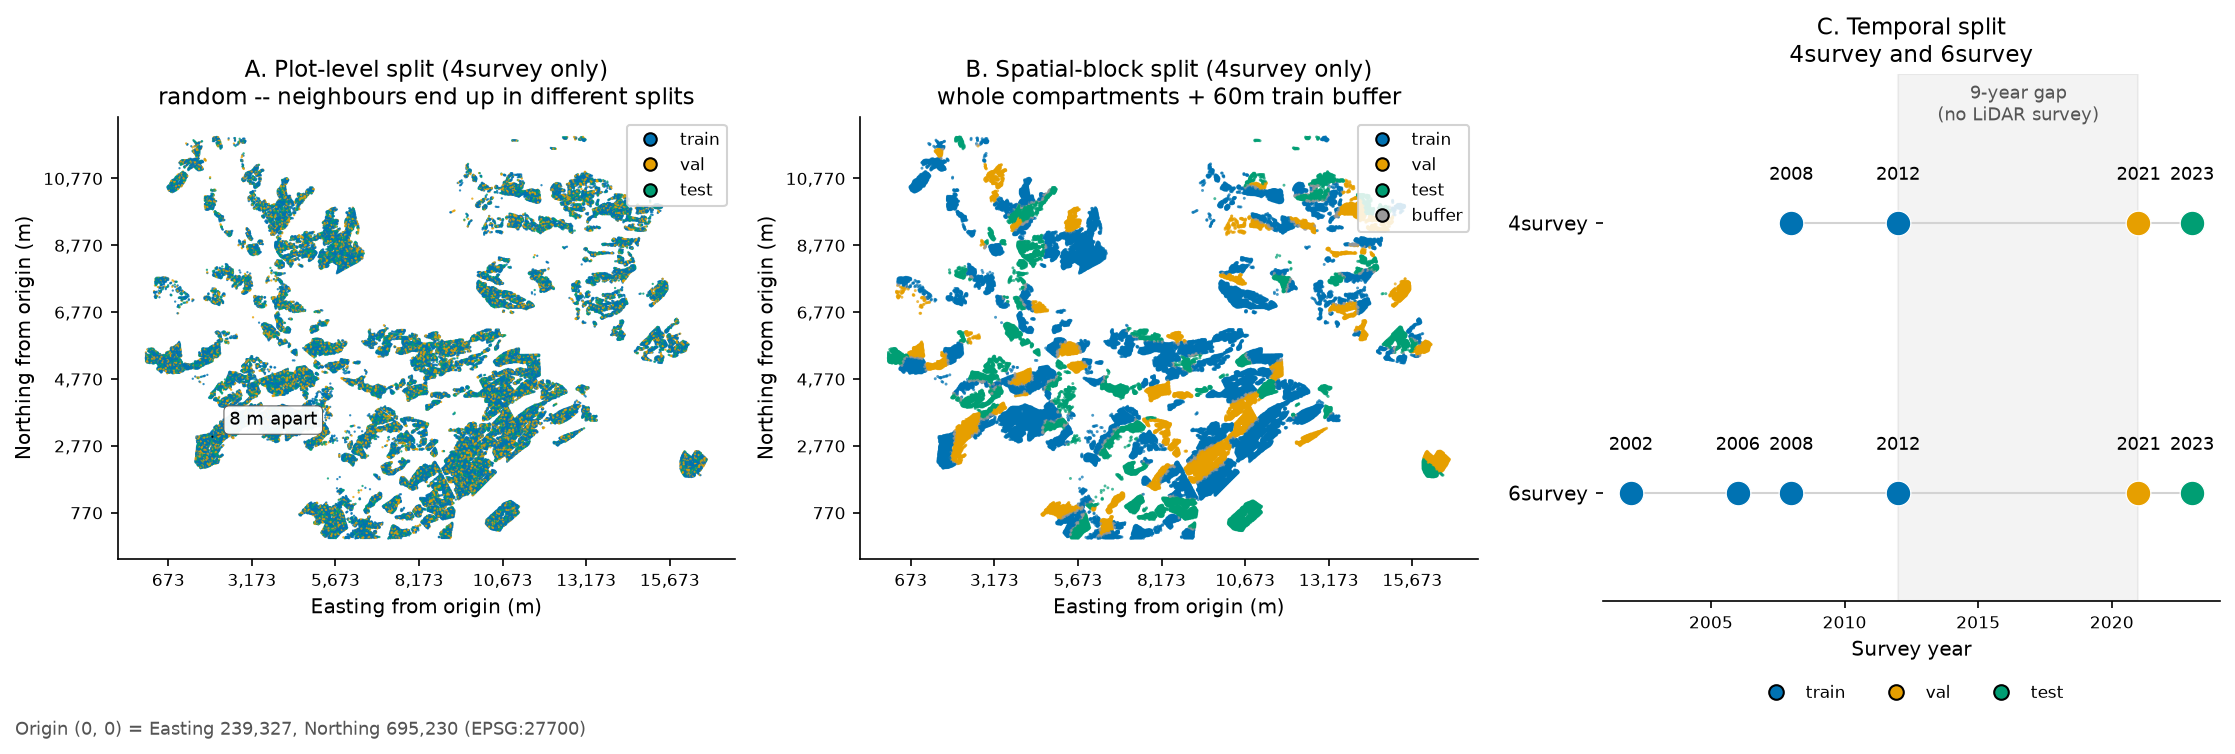

In [8]:
# Shared origin for panels A and B, so both maps use the SAME relative coordinate frame --
# picked as the minimum x/y across all 4survey plots, i.e. roughly the south-west corner of
# the plotted area. Axis ticks then show metres from this point rather than raw OS grid
# coordinates (which are large, six-digit numbers with no intuitive meaning on their own),
# and the true grid reference of (0, 0) is annotated once on the figure so the map can still
# be tied back to a real location.
ORIGIN_X = plots_df["x"].min()
ORIGIN_Y = plots_df["y"].min()


def plot_split_map(df, split_col, title, ax, point_size=1.2, alpha=0.8, legend_loc="upper right"):
    # One consistent colour per split label -- reused everywhere in this notebook, and
    # written as its own function so a later Data-chapter figure can reuse the same styling
    # (see the markdown note above).
    split_colors = {"train": COLOR_TRAIN, "val": COLOR_VAL, "test": COLOR_TEST, "buffer": COLOR_BUFFER}

    # Shuffle row order ONCE before drawing, then draw every point in a SINGLE scatter()
    # call with a per-point colour array. Looping split-by-split (train, then val, then
    # test) draws each split as its own layer, so whichever split is looped last always
    # sits on top wherever points overlap -- with ~57k points on a small map, that made the
    # map read as almost solid green (test, drawn last) regardless of the true local mix.
    # Shuffling means overlap is resolved randomly, which actually shows the random
    # interleaving the plot-level split produces.
    shuffled_df = df.sample(frac=1.0, random_state=0)
    point_colors = shuffled_df[split_col].map(split_colors)
    ax.scatter(shuffled_df["x"], shuffled_df["y"], c=point_colors, s=point_size, alpha=alpha, linewidths=0)

    ax.set_title(title, fontsize=11)
    ax.set_aspect("equal")

    # Relative-distance tick labels (metres from ORIGIN_X/ORIGIN_Y) instead of no ticks at
    # all -- gives the map a real sense of scale and orientation without cluttering it with
    # six-digit OS grid numbers.
    ax.xaxis.set_major_formatter(FuncFormatter(lambda value, pos: f"{value - ORIGIN_X:,.0f}"))
    ax.yaxis.set_major_formatter(FuncFormatter(lambda value, pos: f"{value - ORIGIN_Y:,.0f}"))
    ax.tick_params(labelsize=8)
    ax.set_xlabel("Easting from origin (m)", fontsize=9.5)
    ax.set_ylabel("Northing from origin (m)", fontsize=9.5)

    legend_handles = [
        plt.Line2D([0], [0], marker="o", color="none", markerfacecolor=color, markersize=6, label=name)
        for name, color in split_colors.items()
        if (df[split_col] == name).any()
    ]
    # loc="upper right" with no bbox_to_anchor override keeps the legend fully INSIDE the
    # axes frame -- "upper left" previously sat on top of the densest part of the point
    # cloud in this data, making it hard to read either the legend or the points under it.
    ax.legend(handles=legend_handles, loc=legend_loc, fontsize=8, frameon=True, framealpha=0.85, borderpad=0.4)


fig, (ax_a, ax_b, ax_c) = plt.subplots(1, 3, figsize=(15, 5))

# --- Panel A: plot-level split (random shuffle -- leaks spatially) ---
plots_df["plot_split"] = plot_level_split(plots_df, seed=42)
plot_split_map(plots_df, "plot_split", "A. Plot-level split (4survey only)\nrandom -- neighbours end up in different splits", ax_a)

# Distance callout: this is the figure's concrete evidence for the plot-level split's
# leakage problem, matching the chapter's own figure spec ("at least one held-out plot's
# nearest training-plot neighbour explicitly connected by a short line/arrow labelled with
# its distance in metres"). It finds the single closest real held-out/train pair under this
# actual split and reports their true distance -- turning "neighbouring plots can leak
# location information" from an abstract claim into one measured number (here, ~8m), which
# is the whole point of Panel A existing separately from Panel B.
from scipy.spatial import cKDTree

held_out_plots = plots_df[plots_df["plot_split"].isin(["val", "test"])]
train_plots_a = plots_df[plots_df["plot_split"] == "train"]
train_tree = cKDTree(train_plots_a[["x", "y"]].values)
distances, nearest_idx = train_tree.query(held_out_plots[["x", "y"]].values, k=1)
closest_pair_row = distances.argmin()
closest_distance = distances[closest_pair_row]
held_out_point = held_out_plots.iloc[closest_pair_row]
train_point = train_plots_a.iloc[nearest_idx[closest_pair_row]]

ax_a.annotate(
    "", xy=(train_point["x"], train_point["y"]), xytext=(held_out_point["x"], held_out_point["y"]),
    arrowprops=dict(arrowstyle="-", color="black", linewidth=1),
)
# Callout text offset well clear of the connecting line/points (previously sat exactly on
# the midpoint and covered whatever else was underneath it) -- nudged up and to the side by
# a fraction of the plotted extent, with a solid background box so it stays legible over
# the point cloud wherever it lands.
x_extent = plots_df["x"].max() - plots_df["x"].min()
y_extent = plots_df["y"].max() - plots_df["y"].min()
callout_x = (train_point["x"] + held_out_point["x"]) / 2 + 0.03 * x_extent
callout_y = (train_point["y"] + held_out_point["y"]) / 2 + 0.03 * y_extent
ax_a.annotate(
    f"{closest_distance:.0f} m apart", xy=((train_point["x"] + held_out_point["x"]) / 2, (train_point["y"] + held_out_point["y"]) / 2),
    xytext=(callout_x, callout_y), fontsize=8.5, ha="left",
    bbox=dict(boxstyle="round", facecolor="white", edgecolor=COLOR_NEUTRAL_EDGE, linewidth=0.5, alpha=0.95),
    arrowprops=dict(arrowstyle="-", color=COLOR_NEUTRAL_EDGE, linewidth=0.6),
)

print(f"Panel A callout: closest held-out/train pair is {closest_distance:.1f} m apart")

# --- Panel B: spatial-block split with buffer ---
plots_df["buffered_split"] = spatial_block_split(
    plots_df, block_col="cpmt", buffer_distance=SPATIAL_BUFFER_METRES,
    coordinates_df=coordinates_df, seed=42,
)
plot_split_map(
    plots_df, "buffered_split",
    f"B. Spatial-block split (4survey only)\nwhole compartments + {SPATIAL_BUFFER_METRES}m train buffer",
    ax_b, point_size=2, alpha=0.7,
)

# States where the origin actually is in real coordinates, so the relative axes above can
# still be tied back to an absolute location.
fig.text(
    0.01, 0.01, f"Origin (0, 0) = Easting {ORIGIN_X:,.0f}, Northing {ORIGIN_Y:,.0f} (EPSG:27700)",
    fontsize=8.5, color=COLOR_NEUTRAL_EDGE,
)

# --- Panel C: temporal split, BOTH cohorts as a horizontal swimlane each ---
TEMPORAL_YEARS = {
    "4survey": {"train_years": [2008, 2012], "val_years": [2021], "test_years": [2023]},
    "6survey": {"train_years": [2002, 2006, 2008, 2012], "val_years": [2021], "test_years": [2023]},
}
COHORT_ROW = {"4survey": 1, "6survey": 0}
COHORT_MASTER = {"4survey": master_df, "6survey": master_df_6survey}
split_colors = {"train": COLOR_TRAIN, "val": COLOR_VAL, "test": COLOR_TEST}

for cohort_name, row_y in COHORT_ROW.items():
    cohort_master_df = COHORT_MASTER[cohort_name].copy()
    cohort_master_df["temporal_split"] = temporal_split(
        cohort_master_df, year_col="LiDAR_year", **TEMPORAL_YEARS[cohort_name],
    )
    cohort_years = sorted(cohort_master_df["LiDAR_year"].unique())
    ax_c.plot([min(cohort_years), max(cohort_years)], [row_y, row_y], color="lightgrey", zorder=1, linewidth=1)
    for year in cohort_years:
        year_split = cohort_master_df.loc[cohort_master_df["LiDAR_year"] == year, "temporal_split"].iloc[0]
        ax_c.scatter(year, row_y, s=140, color=split_colors[year_split], zorder=3, edgecolors="white", linewidths=0.6)
        ax_c.text(year, row_y + 0.16, str(year), ha="center", fontsize=8.5)

ax_c.set_yticks([0, 1])
ax_c.set_yticklabels(["6survey", "4survey"], fontsize=9.5)
ax_c.set_ylim(-0.4, 1.55)

# Both cohorts train up to 2012 and then jump to a 2021 validation survey, so the 9-year gap
# is shared -- shown once as a shaded band spanning both rows rather than duplicated per row.
ax_c.axvspan(2012, 2021, color=COLOR_NEUTRAL_EDGE, alpha=0.07, zorder=0)
ax_c.text(
    (2012 + 2021) / 2, 1.38, "9-year gap\n(no LiDAR survey)",
    ha="center", fontsize=8.5, color=COLOR_NEUTRAL_EDGE,
)

ax_c.set_xlabel("Survey year", fontsize=9.5)
ax_c.set_title("C. Temporal split\n4survey and 6survey", fontsize=11)
ax_c.tick_params(axis="x", labelsize=8)
for spine in ["left", "right", "top"]:
    ax_c.spines[spine].set_visible(False)
# Direct labels instead of a legend, since there are only 3 colours -- placed close beneath
# the axis (previously had a large, mostly-empty gap here).
legend_handles = [
    plt.Line2D([0], [0], marker="o", color="none", markerfacecolor=color, markersize=7, label=name)
    for name, color in split_colors.items()
]
ax_c.legend(handles=legend_handles, loc="lower center", ncol=3, fontsize=8, frameon=False, bbox_to_anchor=(0.5, -0.22))

plt.tight_layout()
plt.show()

## Figure: `fig:splits-combined`, two-panel version (A+B only, no temporal panel)

The temporal split (Panel C above) was constructed for Q3 (`models/common/splits.py`'s
`temporal_split()`, wired into every Q3 model's run script via `--split-type temporal`) but
never carried through to a reported result -- the chapter's scope narrowed to the
spatial-block comparison and the Q1/Q2 attribution questions. Keeping Panel C in the
submitted figure would show a split the dissertation doesn't actually use, so this cell
reproduces Panels A and B only, unchanged, for `fig:splits-combined` as it should appear in
the final draft. Reuses `plots_df`, `ORIGIN_X`/`ORIGIN_Y`, and `plot_split_map()` already
computed by the cell above -- nothing recomputed. The 3-panel cell above is left in place as
a reference, not deleted.

Panel A callout: closest held-out/train pair is 8.2 m apart


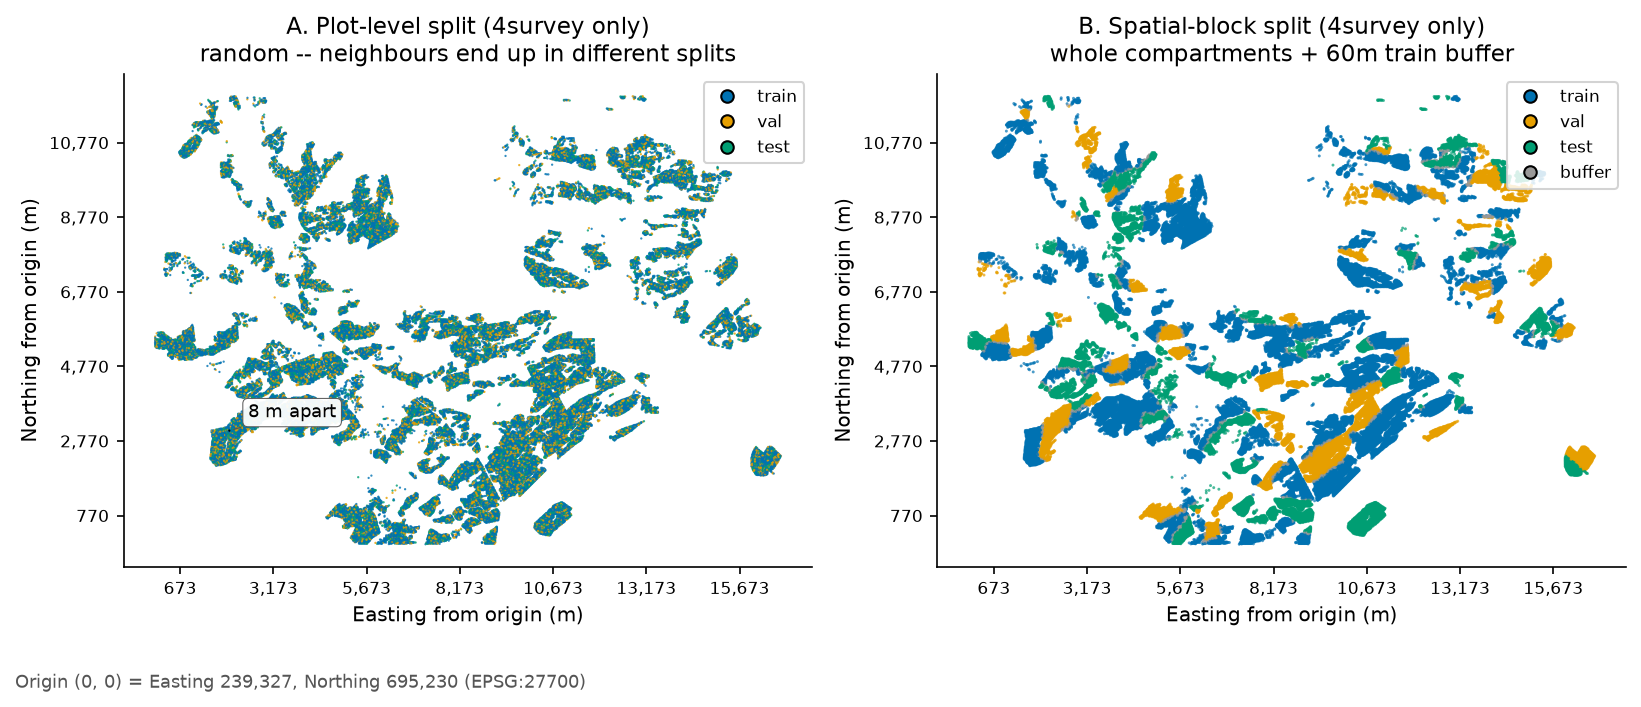

In [9]:
from scipy.spatial import cKDTree

fig, (ax_a, ax_b) = plt.subplots(1, 2, figsize=(11, 5))

# --- Panel A: plot-level split (random shuffle -- leaks spatially) ---
plot_split_map(plots_df, "plot_split", "A. Plot-level split (4survey only)\nrandom -- neighbours end up in different splits", ax_a)

# Same closest-pair callout as the 3-panel cell above, recomputed here since this is a fresh
# Panel A axis -- turns "neighbouring plots can leak location information" into one measured
# number rather than an abstract claim.
held_out_plots = plots_df[plots_df["plot_split"].isin(["val", "test"])]
train_plots_a = plots_df[plots_df["plot_split"] == "train"]
train_tree = cKDTree(train_plots_a[["x", "y"]].values)
distances, nearest_idx = train_tree.query(held_out_plots[["x", "y"]].values, k=1)
closest_pair_row = distances.argmin()
closest_distance = distances[closest_pair_row]
held_out_point = held_out_plots.iloc[closest_pair_row]
train_point = train_plots_a.iloc[nearest_idx[closest_pair_row]]

ax_a.annotate(
    "", xy=(train_point["x"], train_point["y"]), xytext=(held_out_point["x"], held_out_point["y"]),
    arrowprops=dict(arrowstyle="-", color="black", linewidth=1),
)
x_extent = plots_df["x"].max() - plots_df["x"].min()
y_extent = plots_df["y"].max() - plots_df["y"].min()
callout_x = (train_point["x"] + held_out_point["x"]) / 2 + 0.03 * x_extent
callout_y = (train_point["y"] + held_out_point["y"]) / 2 + 0.03 * y_extent
ax_a.annotate(
    f"{closest_distance:.0f} m apart", xy=((train_point["x"] + held_out_point["x"]) / 2, (train_point["y"] + held_out_point["y"]) / 2),
    xytext=(callout_x, callout_y), fontsize=8.5, ha="left",
    bbox=dict(boxstyle="round", facecolor="white", edgecolor=COLOR_NEUTRAL_EDGE, linewidth=0.5, alpha=0.95),
    arrowprops=dict(arrowstyle="-", color=COLOR_NEUTRAL_EDGE, linewidth=0.6),
)

print(f"Panel A callout: closest held-out/train pair is {closest_distance:.1f} m apart")

# --- Panel B: spatial-block split with buffer ---
plot_split_map(
    plots_df, "buffered_split",
    f"B. Spatial-block split (4survey only)\nwhole compartments + {SPATIAL_BUFFER_METRES}m train buffer",
    ax_b, point_size=2, alpha=0.7,
)

# States where the origin actually is in real coordinates, so the relative axes above can
# still be tied back to an absolute location.
fig.text(
    0.01, 0.01, f"Origin (0, 0) = Easting {ORIGIN_X:,.0f}, Northing {ORIGIN_Y:,.0f} (EPSG:27700)",
    fontsize=8.5, color=COLOR_NEUTRAL_EDGE,
)

plt.tight_layout()
plt.show()

# Uncomment once this is the finalised figure, per this notebook's own save convention
# (see the intro cell): plt.savefig(FIGURES_DIR / "splits_combined_AB.png")

## Comparison: real polygon fill instead of point markers (panels A and B)

Panels A and B above draw every plot as a point marker, sized larger than its true ~20m
footprint (a standard cartographic technique for features below the pixel resolution -- see
the earlier discussion). This section tries the alternative: filling each plot's OWN real
polygon (from the raw GeoPackage, `data/raw/LiDAR_Years_All_7jul.gpkg`), which sidesteps the
sub-pixel problem entirely rather than working around it.

**This works differently for A and B, because the two splits are assigned at different
spatial units:**
- **Panel B** (spatial-block split) assigns a whole *compartment* to train/val/test -- every
  plot in a compartment gets the same label -- so the compartment polygon (plot polygons
  dissolved by `cpmt`) is the true unit, and filling it is unambiguous.
- **Panel A** (plot-level split) assigns EACH PLOT independently -- one compartment can (and
  usually does) contain a random mix of train/val/test plots. There is no single colour a
  whole compartment could honestly be filled with here. So Panel A below fills each
  individual plot's own small polygon at true scale, WITHOUT dissolving by compartment --
  same real geometry source as B, just not merged, because the split itself is not merged
  either.

Panel B also now shows the buffer using the REAL buffered-out plot polygons (individual
plots where `buffered_split == "buffer"`, already computed above), instead of the
outward-buffer-ring approximation used in the earlier scratch test -- this is exact, not an
approximation, since we already have the true per-plot buffer labels.

71,766 plot polygons matched to the 4survey plot list


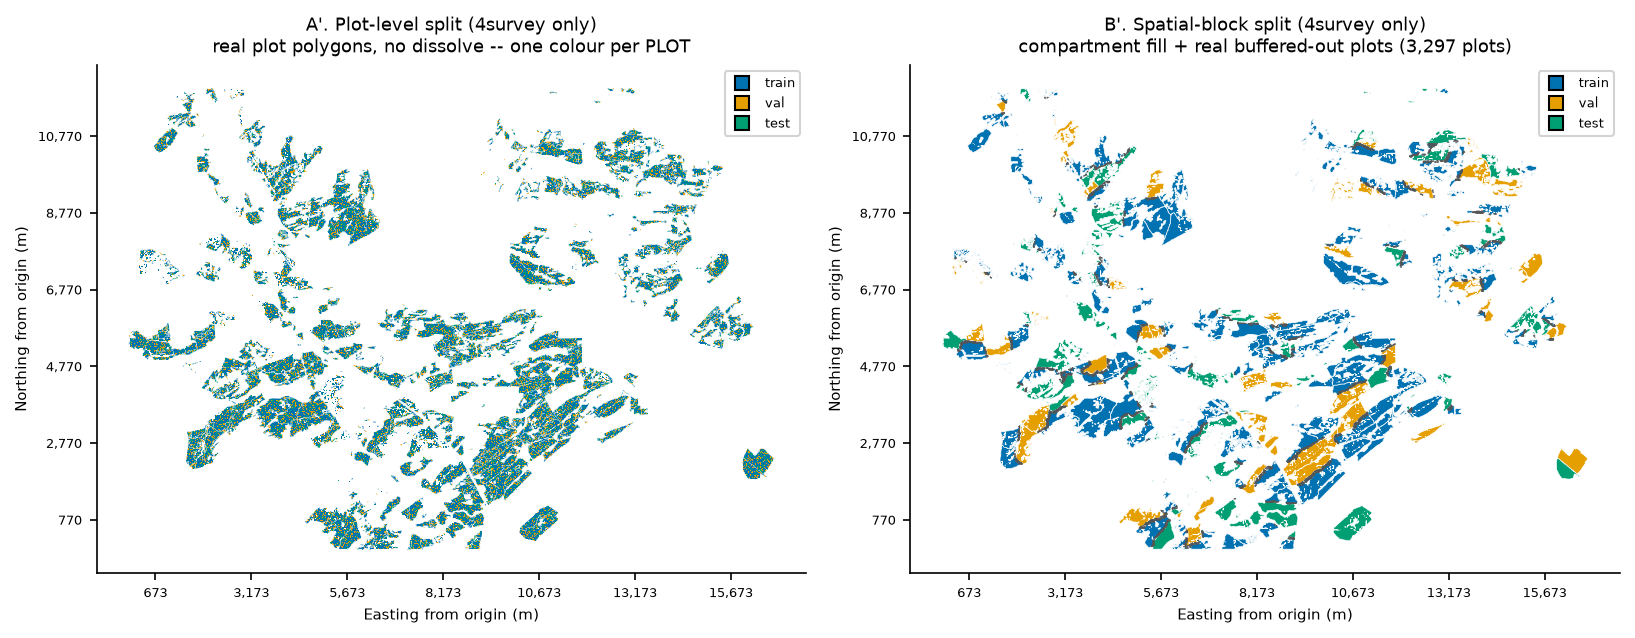

In [10]:
import geopandas as gpd

# Load raw plot polygons, keep one polygon per unique plot (geometry is identical across a
# plot's survey years -- verified separately), then filter to this cohort's own plot list.
raw_plot_polygons = gpd.read_file(project_root / "data" / "raw" / "LiDAR_Years_All_7jul.gpkg", layer="LiDAR_Years")
raw_plot_polygons = raw_plot_polygons.drop_duplicates("identification")[["identification", "cpmt", "geometry"]]
plot_polygons = raw_plot_polygons[raw_plot_polygons["identification"].isin(plots_df["identification"])].copy()

# Attach the same split labels already computed above (plot_split for A, buffered_split for
# B) by joining on identification -- no split logic is recomputed here.
plot_polygons = plot_polygons.merge(
    plots_df[["identification", "plot_split", "buffered_split"]], on="identification", how="left",
)
print(f"{len(plot_polygons):,} plot polygons matched to the 4survey plot list")

split_colors_abbr = {"train": COLOR_TRAIN, "val": COLOR_VAL, "test": COLOR_TEST}

fig, (ax_a2, ax_b2) = plt.subplots(1, 2, figsize=(11, 5.5))

# --- Panel A': every plot's own true polygon, filled by its plot-level split label ---
for split_name, color in split_colors_abbr.items():
    subset = plot_polygons[plot_polygons["plot_split"] == split_name]
    subset.plot(ax=ax_a2, color=color, edgecolor="none")
ax_a2.set_title("A'. Plot-level split (4survey only)\nreal plot polygons, no dissolve -- one colour per PLOT", fontsize=8.5)

# --- Panel B': compartment polygons (dissolved by cpmt), filled by their ORIGINAL split ---
# (before buffering -- buffering only ever removes train plots, it never changes which
# split a compartment was originally assigned to).
compartment_polygons = plot_polygons.dissolve(by="cpmt").reset_index()
compartment_to_split = plots_df.set_index("cpmt")["buffered_split"]
# A compartment's ORIGINAL split (pre-buffer) is recovered from any of its own train/val/test
# plots -- buffered plots still belonged to a train compartment, so this is only needed to
# label compartments that lost ALL their plots to buffering (rare, but possible for a very
# small compartment -- see the earlier scratch test's "2 fully-buffered compartments" note).
plot_original_split = plots_df["buffered_split"].where(plots_df["buffered_split"] != "buffer", "train")
compartment_to_original_split = plots_df.assign(_orig=plot_original_split).groupby("cpmt")["_orig"].first()
compartment_polygons["split"] = compartment_polygons["cpmt"].map(compartment_to_original_split)

for split_name, color in split_colors_abbr.items():
    subset = compartment_polygons[compartment_polygons["split"] == split_name]
    subset.plot(ax=ax_b2, color=color, edgecolor="white", linewidth=0.3)

# The REAL buffered-out train plots (exact, not an approximated ring), hatched on top.
buffered_out_plots = plot_polygons[plot_polygons["buffered_split"] == "buffer"]
buffered_out_plots.plot(ax=ax_b2, facecolor="none", edgecolor=COLOR_NEUTRAL_EDGE, hatch="///", linewidth=0.3)

ax_b2.set_title(
    f"B'. Spatial-block split (4survey only)\ncompartment fill + real buffered-out plots ({len(buffered_out_plots):,} plots)",
    fontsize=8.5,
)

for ax in (ax_a2, ax_b2):
    ax.set_aspect("equal")
    ax.xaxis.set_major_formatter(FuncFormatter(lambda value, pos: f"{value - ORIGIN_X:,.0f}"))
    ax.yaxis.set_major_formatter(FuncFormatter(lambda value, pos: f"{value - ORIGIN_Y:,.0f}"))
    ax.tick_params(labelsize=6)
    ax.set_xlabel("Easting from origin (m)", fontsize=7)
    ax.set_ylabel("Northing from origin (m)", fontsize=7)
    legend_handles = [
        plt.Line2D([0], [0], marker="s", color="none", markerfacecolor=c, markersize=7, label=n)
        for n, c in split_colors_abbr.items()
    ]
    ax.legend(handles=legend_handles, loc="upper right", fontsize=6, frameon=True, framealpha=0.85, borderpad=0.4)

plt.tight_layout()
plt.show()

## Shared helper for the schematic figures

Figures `fig:pipeline-overview`, `fig:model-architecture`, and the mechanism part of
`fig:rq3-attribution` have no underlying dataset -- they are diagrams of the pipeline/architecture
itself. The chapter already has final caption text for each (written earlier in this project), so the
diagrams below are built to match that caption text exactly.

In [11]:
def new_schematic_axes(figsize, xlim, ylim):
    fig, ax = plt.subplots(figsize=figsize)
    ax.set_xlim(*xlim)
    ax.set_ylim(*ylim)
    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_visible(False)
    return fig, ax

print("Schematic helpers ready.")

Schematic helpers ready.


## Box/arrow drawing + icon library

Two things these helpers take care of for every schematic figure below:
1. **Correct z-order.** Boxes render on a higher `zorder` than arrows, so a box always sits
   cleanly on top of any arrow line that happens to pass near it, regardless of draw order in
   the code -- no arrow ever visibly cuts across an unrelated box.
2. **Icons instead of plain labelled rectangles.** Random Forest/XGBoost get a hand-drawn
   decision-tree flowchart glyph (independent trees for Random Forest, a chained sequence for
   XGBoost -- deliberately not a nature/pine-tree icon, since the actual study site is also a
   real forest), DNN/PINN get an actual small node-and-connection network, environmental/
   terrain inputs get a small stacked-layers icon, and Elastic Net/NLME/GNNWR/CR-curve each get
   their own small representative glyph. All of this is built from plain Matplotlib patches
   (`Circle`, `Polygon`, `Rectangle`) -- no external image generation, so every shape is exactly
   reproducible from this code.

In [12]:
def draw_box_v2(ax, x, y, width, height, label, facecolor=COLOR_NEUTRAL_BOX, edgecolor=COLOR_NEUTRAL_EDGE, fontsize=9, label_dy=0.0):
    box = FancyBboxPatch(
        (x, y), width, height,
        boxstyle="round,pad=0.02,rounding_size=0.03",
        facecolor=facecolor, edgecolor=edgecolor, linewidth=1.2, zorder=3,
    )
    ax.add_patch(box)
    if label:
        ax.text(x + width / 2, y + height / 2 + label_dy, label, ha="center", va="center", fontsize=fontsize, wrap=True, zorder=4)
    return box


def draw_arrow_v2(ax, start_xy, end_xy, style="-|>", color=COLOR_NEUTRAL_EDGE, linestyle="solid"):
    arrow = FancyArrowPatch(
        start_xy, end_xy, arrowstyle=style, mutation_scale=12,
        color=color, linewidth=1.2, linestyle=linestyle, zorder=1,
    )
    ax.add_patch(arrow)
    return arrow


def draw_decision_tree_icon(ax, cx, cy, size, color):
    # A small binary-tree FLOWCHART (root node branching to two children, each branching to
    # two leaves) -- the actual ML "decision tree" concept, deliberately NOT a pine-tree
    # silhouette. This project's whole subject is a real forest, so a nature-tree icon for
    # "the Random Forest algorithm" would be genuinely ambiguous here; a branching-node
    # diagram is what a decision tree actually looks like as a model.
    root = (cx, cy + size * 0.42)
    child_left = (cx - size * 0.30, cy)
    child_right = (cx + size * 0.30, cy)
    leaves = [
        (cx - size * 0.46, cy - size * 0.42), (cx - size * 0.14, cy - size * 0.42),
        (cx + size * 0.14, cy - size * 0.42), (cx + size * 0.46, cy - size * 0.42),
    ]
    edges = [
        (root, child_left), (root, child_right),
        (child_left, leaves[0]), (child_left, leaves[1]),
        (child_right, leaves[2]), (child_right, leaves[3]),
    ]
    for (x0, y0), (x1, y1) in edges:
        ax.plot([x0, x1], [y0, y1], color=color, linewidth=1.0, zorder=5)
    for node in [root, child_left, child_right]:
        ax.add_patch(plt.Circle(node, size * 0.075, facecolor=color, edgecolor=COLOR_NEUTRAL_EDGE, linewidth=0.5, zorder=6))
    for leaf in leaves:
        ax.add_patch(plt.Circle(leaf, size * 0.055, facecolor="white", edgecolor=color, linewidth=0.9, zorder=6))


def draw_random_forest_icon(ax, cx, cy, size, color):
    # Ensemble = several INDEPENDENT decision trees with no connections between them
    # (bagging: each tree trained separately, votes/averages at the end) -- distinguishes it
    # from XGBoost's explicitly CHAINED trees below, even at small icon sizes where a "+"
    # sign alone might not survive the scale-down.
    draw_decision_tree_icon(ax, cx - size * 0.36, cy, size * 0.6, color)
    draw_decision_tree_icon(ax, cx, cy, size * 0.6, color)
    draw_decision_tree_icon(ax, cx + size * 0.36, cy, size * 0.6, color)


def draw_xgboost_icon(ax, cx, cy, size, color):
    # Sequential boosting = the SAME decision-tree glyph as Random Forest, but explicitly
    # chained by small arrows (each tree corrects the residual of the one before it) --
    # the connecting arrows, not a different tree shape, are what makes this read as
    # "sequential" rather than "independent ensemble".
    positions = [cx - size * 0.58, cx, cx + size * 0.58]
    for i, px in enumerate(positions):
        draw_decision_tree_icon(ax, px, cy, size * 0.55, color)
        if i < len(positions) - 1:
            # A small, icon-proportioned arrow -- draw_arrow()'s usual mutation_scale=12 is
            # sized for full-diagram arrows between boxes and would look oversized here.
            small_arrow = FancyArrowPatch(
                (px + size * 0.3, cy), (positions[i + 1] - size * 0.3, cy),
                arrowstyle="-|>", mutation_scale=5, color=COLOR_NEUTRAL_EDGE, linewidth=0.8, zorder=5,
            )
            ax.add_patch(small_arrow)


def draw_node_network_icon(ax, cx, cy, width, height, node_color, line_color=COLOR_NEUTRAL_EDGE, n_input=3, n_hidden=4, n_output=1, node_radius=None):
    # A real small feed-forward network -- input nodes fully connected to hidden nodes,
    # fully connected to output node(s) -- not a box standing in for one.
    node_radius = node_radius or width * 0.045
    input_x, hidden_x, output_x = cx - width / 2, cx, cx + width / 2
    input_ys = np.linspace(cy - height / 2, cy + height / 2, n_input)
    hidden_ys = np.linspace(cy - height / 2, cy + height / 2, n_hidden)
    output_ys = np.linspace(cy - height * 0.15, cy + height * 0.15, n_output)

    for iy in input_ys:
        for hy in hidden_ys:
            ax.plot([input_x, hidden_x], [iy, hy], color=line_color, linewidth=0.5, alpha=0.45, zorder=4)
    for hy in hidden_ys:
        for oy in output_ys:
            ax.plot([hidden_x, output_x], [hy, oy], color=line_color, linewidth=0.5, alpha=0.45, zorder=4)

    for xs, ys in [(input_x, input_ys), (hidden_x, hidden_ys), (output_x, output_ys)]:
        for y in ys:
            ax.add_patch(plt.Circle((xs, y), node_radius, facecolor=node_color, edgecolor=COLOR_NEUTRAL_EDGE, linewidth=0.6, zorder=5))

    return input_x, hidden_x, output_x, input_ys, hidden_ys, output_ys


def draw_cr_curve_icon(ax, cx, cy, width, height, color):
    # A tiny Chapman-Richards-shaped sigmoid H(a), for the CR curve icon -- same qualitative
    # shape as the real fitted curve in the age-linearity figure.
    age = np.linspace(0, 1, 30)
    shape = (1 - np.exp(-4 * age)) ** 0.8
    xs = cx - width / 2 + age * width
    ys = cy - height / 2 + shape * height
    ax.plot(xs, ys, color=color, linewidth=1.6, zorder=5)


def draw_derivative_curve_icon(ax, cx, cy, width, height, color, highlight_point=False):
    # The DERIVATIVE H'(a) of the CR curve above -- a rise-then-decay hump, not a sigmoid.
    # Deliberately a different shape from draw_cr_curve_icon(): H(a) and H'(a) are different
    # functions, so a physics-loss box (which compares against H'(a), not H(a)) should not
    # reuse the plain curve icon -- that was a real inconsistency in the first version of
    # this figure. With highlight_point=True, a single point is marked on the curve, for the
    # "evaluated at one specific age" (mid-age) box, distinguishing it from the general
    # derivative-function icon used in the physics-loss box.
    age = np.linspace(0, 1, 40)
    shape = age * np.exp(-3 * age)
    shape = shape / shape.max()
    xs = cx - width / 2 + age * width
    ys = cy - height / 2 + shape * height
    ax.plot(xs, ys, color=color, linewidth=1.6, zorder=5)
    if highlight_point:
        mark_idx = int(len(age) * 0.4)
        ax.add_patch(plt.Circle((xs[mark_idx], ys[mark_idx]), width * 0.06, facecolor=color, edgecolor=COLOR_NEUTRAL_EDGE, linewidth=0.7, zorder=6))


def draw_linear_icon(ax, cx, cy, width, height, color):
    # A few scattered points plus a straight best-fit-style line, for the linear-regression icon.
    rng = np.random.default_rng(0)
    xs = np.linspace(0, 1, 7)
    ys = 0.15 + 0.7 * xs + rng.normal(0, 0.06, size=xs.shape)
    plot_xs = cx - width / 2 + xs * width
    plot_ys = cy - height / 2 + np.clip(ys, 0, 1) * height
    ax.scatter(plot_xs, plot_ys, s=4, color=COLOR_NEUTRAL_EDGE, zorder=5)
    ax.plot([cx - width / 2, cx + width / 2], [cy - height * 0.25, cy + height * 0.35], color=color, linewidth=1.6, zorder=5)


def draw_elastic_net_icon(ax, cx, cy, width, height, color):
    # A small bar chart with some bars shrunk toward zero -- the recognisable visual idea of
    # regularised regression (some coefficients shrunk out), rather than a generic box.
    bar_heights = [0.9, 0.15, 0.55, 0.05, 0.75]
    bar_w = width / (len(bar_heights) * 1.6)
    xs = np.linspace(cx - width / 2 + bar_w, cx + width / 2 - bar_w, len(bar_heights))
    for x, h in zip(xs, bar_heights):
        ax.add_patch(Rectangle((x - bar_w / 2, cy - height / 2), bar_w, h * height, facecolor=color, edgecolor="none", zorder=5))
    ax.plot([cx - width / 2, cx + width / 2], [cy - height / 2, cy - height / 2], color=COLOR_NEUTRAL_EDGE, linewidth=0.8, zorder=5)


def draw_nlme_icon(ax, cx, cy, width, height, color):
    # Three small groups of points, each with its own short line at a different intercept but
    # similar slope -- the classic "mixed-effects model: same fixed slope, group-specific
    # random intercepts" visual, for the NLME icon.
    rng = np.random.default_rng(1)
    group_offsets = [-0.28, 0.0, 0.28]
    intercepts = [0.2, 0.5, 0.8]
    for gx, intercept in zip(group_offsets, intercepts):
        point_xs = cx + (gx + rng.normal(0, 0.04, size=4)) * width
        point_ys = cy - height / 2 + np.clip(intercept + rng.normal(0, 0.05, size=4), 0.05, 0.95) * height
        ax.scatter(point_xs, point_ys, s=3, color=COLOR_NEUTRAL_EDGE, zorder=5)
        line_x0, line_x1 = cx + (gx - 0.12) * width, cx + (gx + 0.12) * width
        line_y0 = cy - height / 2 + (intercept - 0.08) * height
        line_y1 = cy - height / 2 + (intercept + 0.08) * height
        ax.plot([line_x0, line_x1], [line_y0, line_y1], color=color, linewidth=1.4, zorder=5)


def draw_pinn_icon(ax, cx, cy, width, height, node_color, curve_color=None):
    # A small feed-forward network (same building block as the DNN icon) plus a small curve
    # accent underneath, to mark the physics constraint that distinguishes a PINN from a
    # plain DNN -- reusing draw_node_network_icon rather than a separate implementation, so
    # the "same base network, plus a physics term" relationship is visually literal, not just
    # asserted.
    curve_color = curve_color or COLOR_CURVE
    net_height = height * 0.62
    draw_node_network_icon(ax, cx, cy + height * 0.14, width, net_height, node_color=node_color, n_input=3, n_hidden=3, n_output=1, node_radius=width * 0.05)
    draw_cr_curve_icon(ax, cx, cy - height * 0.36, width * 0.55, height * 0.22, curve_color)


def draw_layers_icon(ax, cx, cy, width, height, colors):
    # A small stack of offset layers, for environmental/terrain "many raster layers" inputs --
    # inspired by a standard GIS-layers illustration, built from plain rectangles.
    n = len(colors)
    layer_h = height / (n * 1.4)
    for i, color in enumerate(colors):
        offset_x = (i - n / 2) * width * 0.09
        offset_y = i * layer_h * 0.85
        ax.add_patch(Rectangle(
            (cx - width / 2 + offset_x, cy - height / 2 + offset_y), width * 0.75, layer_h,
            facecolor=color, edgecolor="white", linewidth=0.8, zorder=5 + i,
        ))


def draw_gnnwr_icon(ax, cx, cy, width, height, color):
    # A location pin (the "geographically weighted" part) beside a tiny 2-node connection
    # (the "neurally weighted" part) -- a compact combination icon for GNNWR.
    pin_cx = cx - width * 0.22
    circle = plt.Circle((pin_cx, cy + height * 0.12), width * 0.16, facecolor=color, edgecolor=COLOR_NEUTRAL_EDGE, linewidth=0.6, zorder=5)
    ax.add_patch(circle)
    tip = plt.Polygon(
        [(pin_cx - width * 0.1, cy + height * 0.02), (pin_cx + width * 0.1, cy + height * 0.02), (pin_cx, cy - height * 0.32)],
        facecolor=color, edgecolor=COLOR_NEUTRAL_EDGE, linewidth=0.6, zorder=5,
    )
    ax.add_patch(tip)
    node_x = cx + width * 0.28
    node_ys = [cy - height * 0.22, cy + height * 0.22]
    for ny in node_ys:
        ax.plot([pin_cx, node_x], [cy, ny], color=COLOR_NEUTRAL_EDGE, linewidth=0.6, alpha=0.6, zorder=4)
        ax.add_patch(plt.Circle((node_x, ny), width * 0.06, facecolor=color, edgecolor=COLOR_NEUTRAL_EDGE, linewidth=0.6, zorder=5))


print("v2 helpers + icon library ready.")

v2 helpers + icon library ready.


## Figure: `fig:pipeline-overview`

**Chapter spec:** an end-to-end flowchart. Raw LiDAR/survey data -> cleaning and cohort construction
(4survey/6survey) -> the four data-splitting strategies (Table `tab:splits-summary`) -> the shared
Set1-4 feature-screening process -> the RQ1/RQ2/RQ3 model families -> the evaluation/interpretation
stage (predictive diagnostics, spatial autocorrelation, feature attribution), ending in a per-plot
coefficient table (GNNWR) and a residual spatial-autocorrelation diagnostic.

Five columns, coloured by pipeline stage, left to right. Each RQ's model family box shows a small
row of hand-drawn icons (a decision-tree flowchart glyph, independent for Random Forest and
chained for XGBoost, node network = DNN, node network + curve accent = PINN, sigmoid =
Chapman-Richards curve, scatter+line = linear regression, shrunk bars = Elastic Net, grouped
intercepts = NLME, pin+node = GNNWR) instead of a parenthetical text list, with a short label
under each icon.

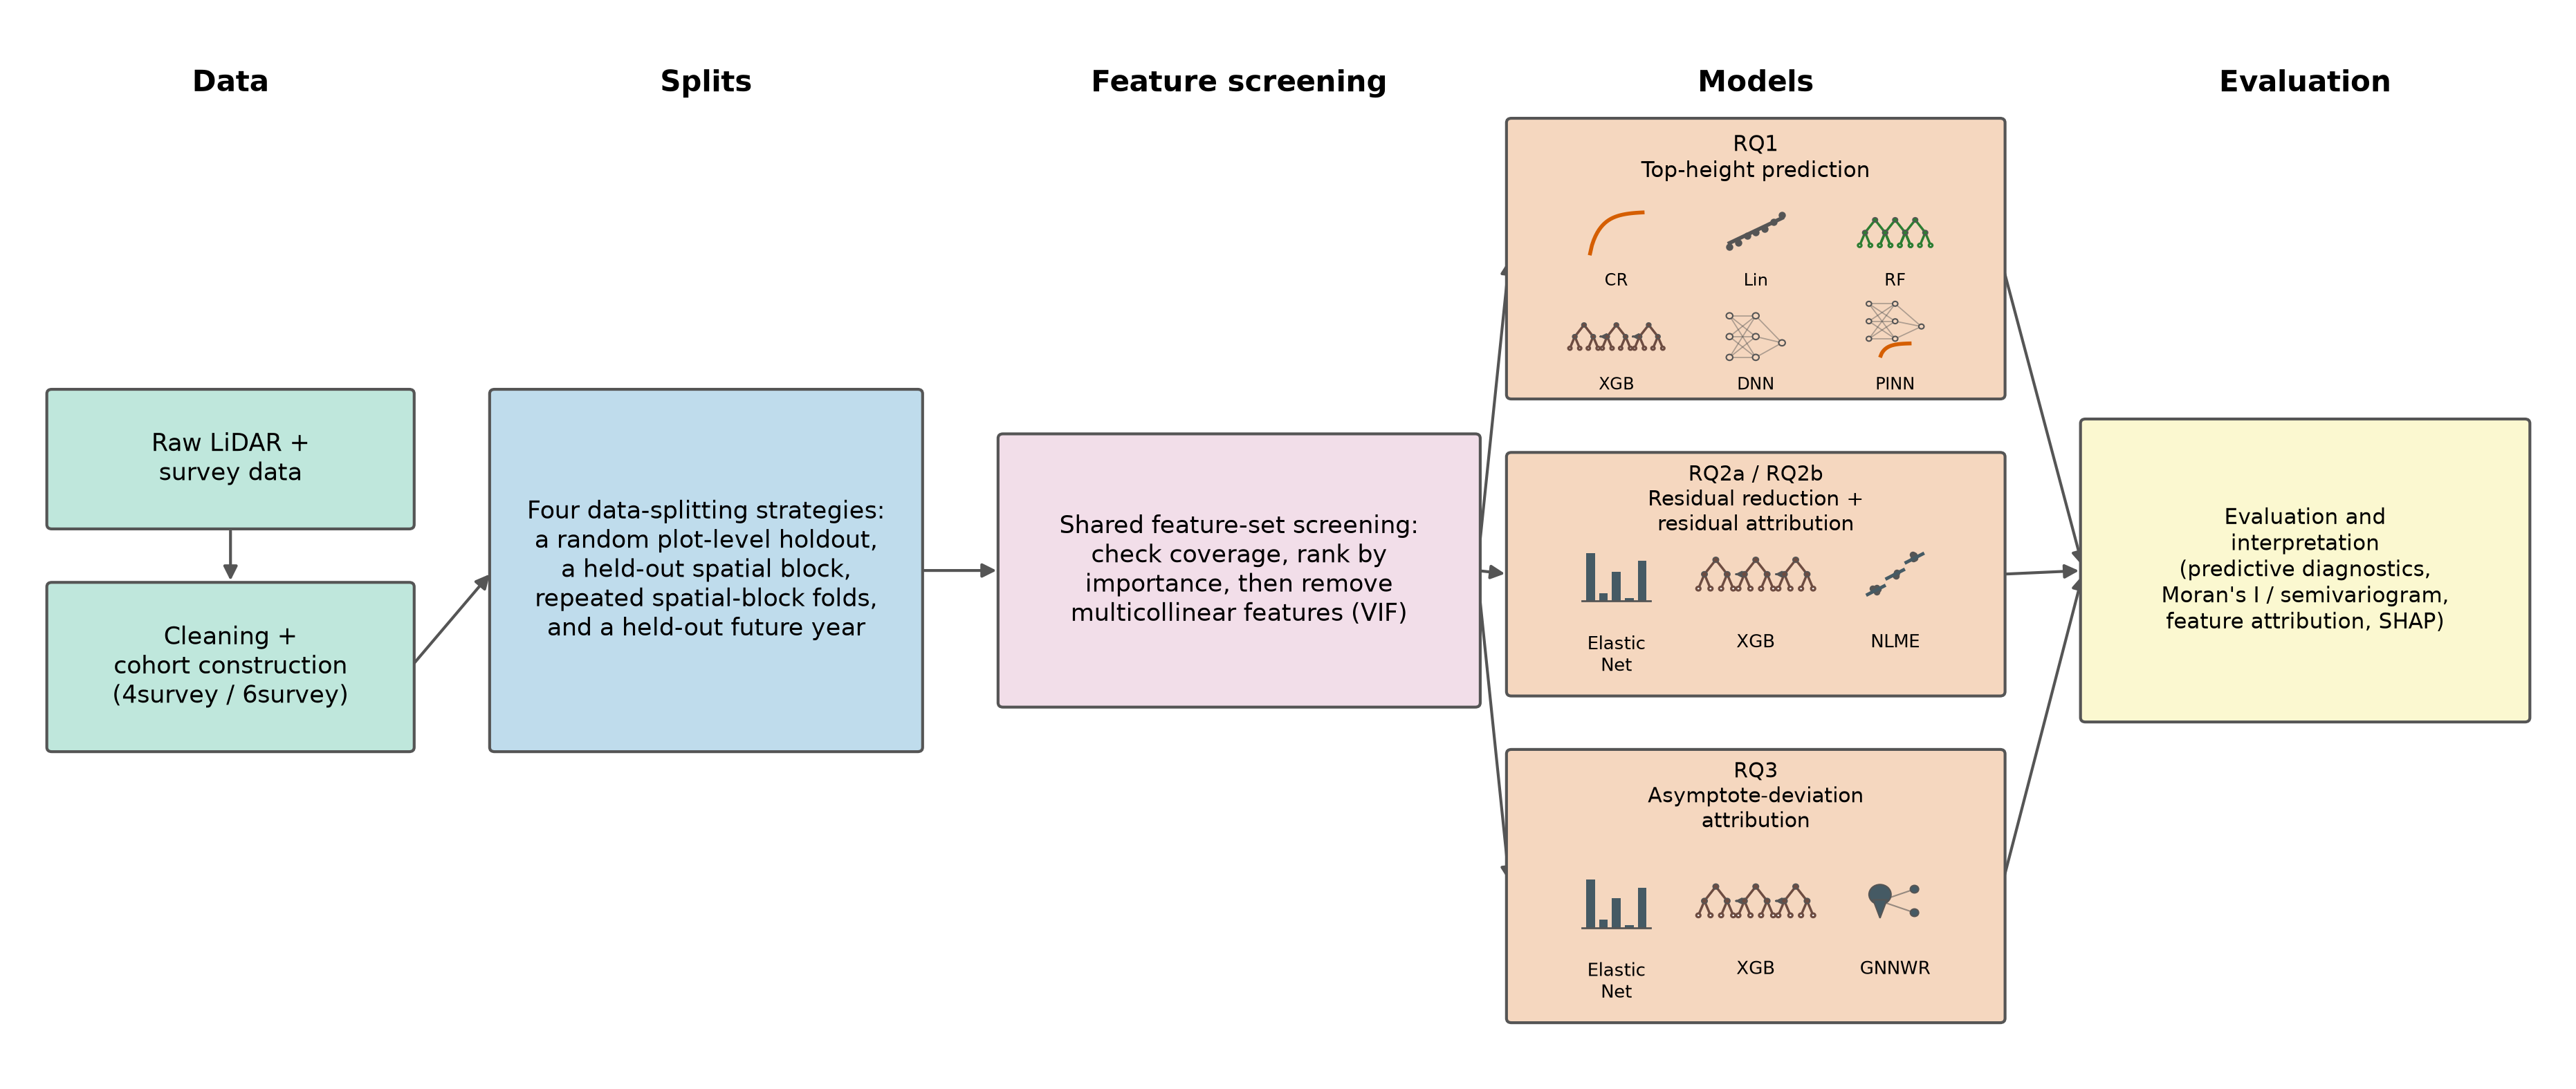

In [13]:
# Colour carries real meaning in this diagram: one colour per PIPELINE STAGE, so a reader
# scanning left to right can see at a glance which stage a box belongs to. Reuses this
# notebook's existing Okabe-Ito constants under new, schematic-only names -- each schematic
# figure is self-contained with its own key, so the same colourblind-safe hue meaning
# something different in a different figure (e.g. COLOR_TEST = "test split" in
# splits-combined vs. "data stage" here) is not ambiguous within either figure on its own.
STAGE_COLOR_DATA = lighten_color(COLOR_TEST, 0.75)
STAGE_COLOR_SPLITS = lighten_color(COLOR_TRAIN, 0.75)
STAGE_COLOR_FEATURES = lighten_color(COLOR_EXAMPLE_4SURVEY, 0.75)
STAGE_COLOR_MODELS = lighten_color(COLOR_CURVE, 0.75)
# Was COLOR_EXAMPLE_6SURVEY ("sky blue" #56B4E9) -- too close to COLOR_TRAIN ("blue" #0072B2,
# already Splits' colour) once both are lightened toward white. Okabe-Ito yellow is the one
# hue in this palette not already assigned to a stage in this figure.
STAGE_COLOR_EVAL = lighten_color("#F0E442", 0.75)

fig, ax = new_schematic_axes(figsize=(15, 6.4), xlim=(0, 15.5), ylim=(0.4, 7.5))
fig.set_dpi(250)  # sharper inline preview -- mpl's own default is ~100-150

# --- Column 4 (Models: RQ1/RQ2/RQ3) is the TALLEST column (6.05 units) and is left exactly
# where it already was -- its title clearance above RQ1 and its distance above the ylim floor
# were already confirmed to work. Every OTHER column is shorter, so instead of leaving them at
# their own separate positions (which is what put empty canvas below Data/Splits/Features and
# below Evaluation -- confirmed directly from the screenshot, not guessed), each one is
# recentred on Models' own vertical centre (3.775), so the leftover space a short column can't
# avoid having is split evenly above/below it instead of dumped entirely underneath it.
MODELS_CENTER_Y = 3.775

# --- Column 1: data --- (pair recentred on MODELS_CENTER_Y; internal gap between the two
# boxes, and each box's own height, are unchanged)
draw_box_v2(ax, 0.2, 4.075, 2.2, 0.9, "Raw LiDAR +\nsurvey data", facecolor=STAGE_COLOR_DATA, fontsize=10)
draw_box_v2(ax, 0.2, 2.575, 2.2, 1.1, "Cleaning +\ncohort construction\n(4survey / 6survey)", facecolor=STAGE_COLOR_DATA, fontsize=10)

# --- Column 2: splits --- (taller, with a paraphrase of what each split actually TESTS, not
# just its name; recentred on MODELS_CENTER_Y)
draw_box_v2(
    ax, 2.9, 2.575, 2.6, 2.4,
    "Four data-splitting strategies:\na random plot-level holdout,\na held-out spatial block,\n"
    "repeated spatial-block folds,\nand a held-out future year",
    facecolor=STAGE_COLOR_SPLITS, fontsize=10,
)

# --- Column 3: features --- (wider, with a paraphrase of the screening STEPS, not just
# arrow-separated keywords; recentred on MODELS_CENTER_Y)
draw_box_v2(
    ax, 6.0, 2.875, 2.9, 1.8,
    "Shared feature-set screening:\ncheck coverage, rank by\nimportance, then remove\n"
    "multicollinear features (VIF)",
    facecolor=STAGE_COLOR_FEATURES, fontsize=10,
)

# --- Column 4: RQ1/2/3 model families, icon rows instead of text lists --- (unchanged from
# the previous version -- these already anchor MODELS_CENTER_Y, nothing here moves)
draw_box_v2(ax, 9.1, 4.95, 3.0, 1.85, "", facecolor=STAGE_COLOR_MODELS)
ax.text(10.6, 6.55, "RQ1\nTop-height prediction", ha="center", va="center", fontsize=9, zorder=4)
rq1_row_x = np.linspace(9.75, 11.45, 3)
draw_cr_curve_icon(ax, rq1_row_x[0], 6.05, 0.32, 0.28, COLOR_CURVE)
draw_linear_icon(ax, rq1_row_x[1], 6.05, 0.32, 0.28, COLOR_NEUTRAL_EDGE)
draw_random_forest_icon(ax, rq1_row_x[2], 6.05, 0.34, "#2E7D32")
for x, label in zip(rq1_row_x, ["CR", "Lin", "RF"]):
    ax.text(x, 5.78, label, ha="center", va="top", fontsize=7, zorder=4)
draw_xgboost_icon(ax, rq1_row_x[0], 5.35, 0.34, "#6D4C41")
draw_node_network_icon(ax, rq1_row_x[1], 5.35, 0.32, 0.28, node_color=STAGE_COLOR_MODELS, n_input=3, n_hidden=3, n_output=1, node_radius=0.02)
draw_pinn_icon(ax, rq1_row_x[2], 5.4, 0.32, 0.38, node_color=STAGE_COLOR_MODELS)
for x, label in zip(rq1_row_x, ["XGB", "DNN", "PINN"]):
    ax.text(x, 5.08, label, ha="center", va="top", fontsize=7, zorder=4)

draw_box_v2(ax, 9.1, 2.95, 3.0, 1.6, "", facecolor=STAGE_COLOR_MODELS)
ax.text(10.6, 4.25, "RQ2a / RQ2b\nResidual reduction +\nresidual attribution", ha="center", va="center", fontsize=8.5, zorder=4)
rq2_icons_x = np.linspace(9.75, 11.45, 3)
draw_elastic_net_icon(ax, rq2_icons_x[0], 3.75, 0.42, 0.36, "#455A64")
draw_xgboost_icon(ax, rq2_icons_x[1], 3.75, 0.42, "#6D4C41")
draw_nlme_icon(ax, rq2_icons_x[2], 3.75, 0.42, 0.36, "#455A64")
for x, label in zip(rq2_icons_x, ["Elastic\nNet", "XGB", "NLME"]):
    ax.text(x, 3.35, label, ha="center", va="top", fontsize=7.5, zorder=4)

draw_box_v2(ax, 9.1, 0.75, 3.0, 1.8, "", facecolor=STAGE_COLOR_MODELS)
ax.text(10.6, 2.25, "RQ3\nAsymptote-deviation\nattribution", ha="center", va="center", fontsize=8.5, zorder=4)
rq3_icons_x = np.linspace(9.75, 11.45, 3)
draw_elastic_net_icon(ax, rq3_icons_x[0], 1.55, 0.42, 0.36, "#455A64")
draw_xgboost_icon(ax, rq3_icons_x[1], 1.55, 0.42, "#6D4C41")
draw_gnnwr_icon(ax, rq3_icons_x[2], 1.55, 0.42, 0.36, "#455A64")
for x, label in zip(rq3_icons_x, ["Elastic\nNet", "XGB", "GNNWR"]):
    ax.text(x, 1.15, label, ha="center", va="top", fontsize=7.5, zorder=4)

# --- Column 5: evaluation --- (recentred on MODELS_CENTER_Y; the two white boxes that used
# to sit below this are still deleted, per earlier feedback)
draw_box_v2(ax, 12.6, 2.775, 2.7, 2.0, "Evaluation and\ninterpretation\n(predictive diagnostics,\nMoran's I / semivariogram,\nfeature attribution, SHAP)", facecolor=STAGE_COLOR_EVAL, fontsize=9)

# --- Arrows ---
# Column 1 is a real sequential chain (data -> cleaning -> splits), not two parallel arrows
# both feeding the splits box directly.
draw_arrow_v2(ax, (1.3, 4.075), (1.3, 3.675))
draw_arrow_v2(ax, (2.4, 3.125), (2.9, MODELS_CENTER_Y))
draw_arrow_v2(ax, (5.5, MODELS_CENTER_Y), (6.0, MODELS_CENTER_Y))
draw_arrow_v2(ax, (8.9, MODELS_CENTER_Y), (9.1, 5.9))
draw_arrow_v2(ax, (8.9, MODELS_CENTER_Y), (9.1, 3.75))
draw_arrow_v2(ax, (8.9, MODELS_CENTER_Y), (9.1, 1.65))
draw_arrow_v2(ax, (12.1, 5.85), (12.6, MODELS_CENTER_Y))
draw_arrow_v2(ax, (12.1, 3.75), (12.6, MODELS_CENTER_Y))
draw_arrow_v2(ax, (12.1, 1.65), (12.6, MODELS_CENTER_Y))

# --- Per-column titles, replacing the old bottom colour key -- each stage already occupies
# one clean vertical column, so a header above it reads faster than a separate legend.
column_titles = [
    (1.3, "Data"), (4.2, "Splits"), (7.45, "Feature screening"),
    (10.6, "Models"), (13.95, "Evaluation"),
]
for x, label in column_titles:
    ax.text(x, 7.15, label, ha="center", va="top", fontsize=12, fontweight="bold", zorder=4)

# ax.set_title("Pipeline overview: data to evaluation", fontsize=15)
plt.tight_layout()
plt.show()


## Figure: `fig:model-architecture`

**Chapter spec:** a block diagram. Age + non-environmental features feed the shared 3x128 trunk to
predict height. Terrain/wind features feed small (16-unit) sub-networks producing an additive
$y_{\max}$ adjustment and, for the rate-conditioned variant, a multiplicative log-space $k$
adjustment. Predicted height and age feed an autograd box (`dH/da`) compared against the analytical
CR derivative to give the physics loss. A second small diagram shows two real, pre-built
consecutive-survey observations of one plot, differenced and compared to the CR derivative at
mid-age, to give the trajectory loss.

The trunk and sub-networks are drawn as actual small feed-forward networks (input/hidden/output
nodes, fully connected), inspired by the standard-DNN/standard-PINN reference figures. Terrain/wind
features get a stacked-layers icon (inspired by a standard GIS-layers illustration) rather than a
plain box.

**Loss notation matches the chapter's own equations exactly** (`eq:physics-loss`,
`eq:trajectory-loss`): $\mathcal{L}_{\text{phys}} = \frac{1}{N}\sum_i(\partial \hat H_i/\partial a_i - H'(a_i))^2$
and $\mathcal{L}_{\text{traj}} = \frac{1}{M}\sum_j\left(\frac{\hat H_{j,\text{later}} - \hat H_{j,\text{earlier}}}{\Delta a_j} - H'(\bar a_j)\right)^2$,
where $H'(a)$ is the CR curve's analytical derivative, $\bar a_j$ is a survey pair's mid-point
age, and $M$ indexes consecutive real survey-pair observations. The two CR-derivative icons are
deliberately different shapes: $H'(a)$ (physics-loss box) is drawn as the general derivative
curve, while $H'(\bar a_j)$ (trajectory-loss box) shows the same curve with one point marked,
since it is evaluated at a single specific age rather than used as a general function.

The "real consecutive-survey pairs" box means literally what the chapter calls $M$: real pairs of
survey visits to the SAME plot at two different real ages (e.g. its 2008 and 2012 rows), used
purely to compute an empirical growth rate $(\hat H_{\text{later}}-\hat H_{\text{earlier}})/\Delta a$
-- not synthetic or interpolated data.

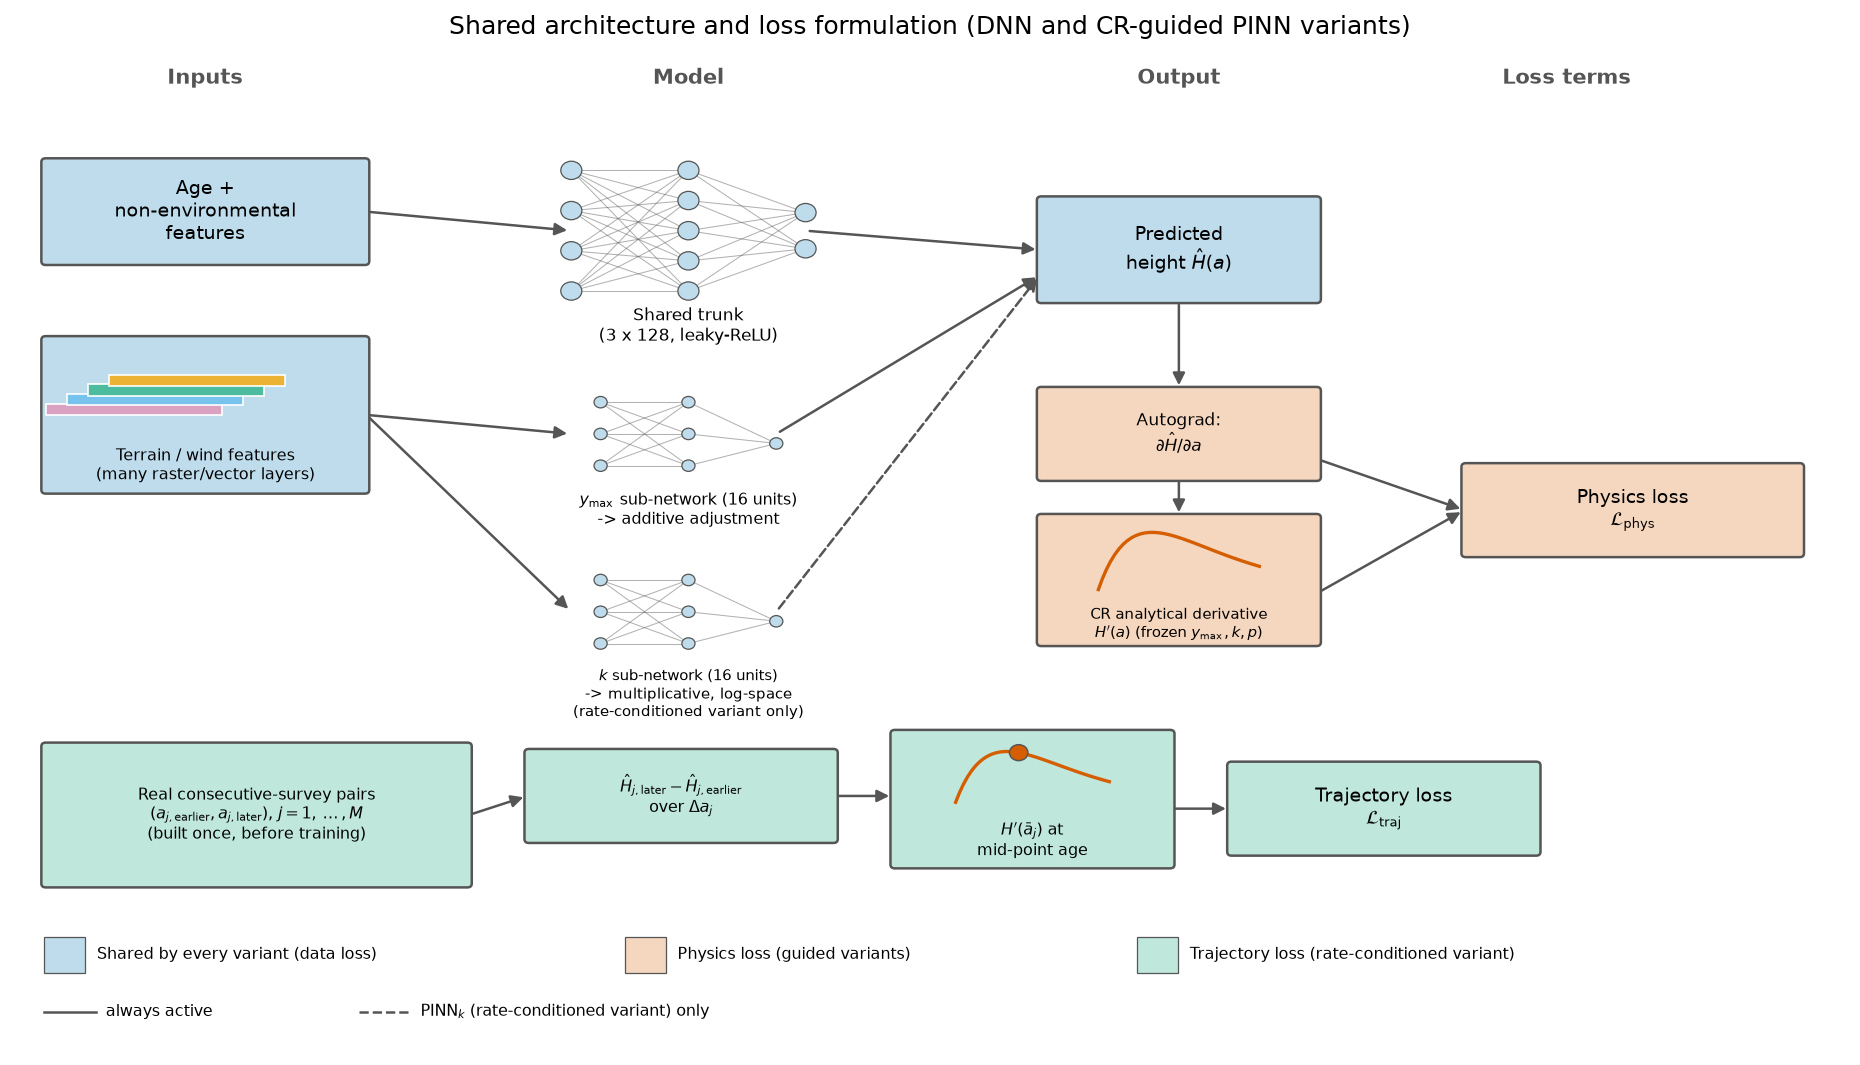

In [14]:
# Colour distinguishes which LOSS TERM each component belongs to -- the actual scientific
# point of this diagram (what the CR-guided network adds beyond plain MSE). Components
# shared by every variant (inputs, trunk, sub-networks, predicted height) use a neutral
# colour, since they are not specific to any one loss term.
LOSS_COLOR_DATA = lighten_color(COLOR_TRAIN, 0.75)
LOSS_COLOR_PHYSICS = lighten_color(COLOR_CURVE, 0.75)
LOSS_COLOR_TRAJECTORY = lighten_color(COLOR_TEST, 0.75)

fig, ax = new_schematic_axes(figsize=(12.5, 7.2), xlim=(0, 12.5), ylim=(-0.3, 7.6))

# --- Column headers, matching the reference figures' "Input Layer / Hidden Layers / Output
# Layer" style labelling -- makes the overall data flow obvious before reading any box. ---
for header_x, header_text in [(1.3, "Inputs"), (4.6, "Model"), (7.95, "Output"), (10.6, "Loss terms")]:
    ax.text(header_x, 7.35, header_text, ha="center", va="center", fontsize=10, fontweight="bold", color=COLOR_NEUTRAL_EDGE)

# --- Inputs ---
draw_box_v2(ax, 0.2, 5.9, 2.2, 0.8, "Age +\nnon-environmental\nfeatures", facecolor=LOSS_COLOR_DATA)
draw_box_v2(ax, 0.2, 4.1, 2.2, 1.2, "", facecolor=LOSS_COLOR_DATA)
draw_layers_icon(ax, 1.3, 4.95, 1.6, 0.5, [lighten_color(COLOR_EXAMPLE_4SURVEY, 0.3), lighten_color(COLOR_EXAMPLE_6SURVEY, 0.2), lighten_color(COLOR_TEST, 0.3), lighten_color(COLOR_VAL, 0.2)])
ax.text(1.3, 4.3, "Terrain / wind features\n(many raster/vector layers)", ha="center", va="center", fontsize=7.5, zorder=6)

# --- Trunk: a real small feed-forward network, not a labelled box ---
draw_node_network_icon(ax, 4.6, 6.15, 1.6, 0.95, node_color=LOSS_COLOR_DATA, n_input=4, n_hidden=5, n_output=2)
ax.text(4.6, 5.4, "Shared trunk\n(3 x 128, leaky-ReLU)", ha="center", va="center", fontsize=8)

# --- Sub-networks: smaller networks, reflecting their smaller (16-unit) size. Extra vertical
# room between icon and caption here specifically -- the 3-line caption below previously
# overlapped the network icon above it. ---
draw_node_network_icon(ax, 4.6, 4.55, 1.2, 0.5, node_color=LOSS_COLOR_DATA, n_input=3, n_hidden=3, n_output=1, node_radius=0.045)
ax.text(4.6, 3.95, "$y_{\\max}$ sub-network (16 units)\n-> additive adjustment", ha="center", va="center", fontsize=7.5)

draw_node_network_icon(ax, 4.6, 3.15, 1.2, 0.5, node_color=LOSS_COLOR_DATA, n_input=3, n_hidden=3, n_output=1, node_radius=0.045)
ax.text(4.6, 2.5, "$k$ sub-network (16 units)\n-> multiplicative, log-space\n(rate-conditioned variant only)", ha="center", va="center", fontsize=7)

# --- Predicted height (a value, not a network -- stays a box) ---
draw_box_v2(ax, 7.0, 5.6, 1.9, 0.8, "Predicted\nheight $\\hat H(a)$", facecolor=LOSS_COLOR_DATA)

# --- Physics loss branch: H'(a), the general derivative FUNCTION (no point marked) ---
draw_box_v2(ax, 7.0, 4.2, 1.9, 0.7, "Autograd:\n$\\partial \\hat H / \\partial a$", facecolor=LOSS_COLOR_PHYSICS, fontsize=8)
draw_box_v2(ax, 7.0, 2.9, 1.9, 1.0, "", facecolor=LOSS_COLOR_PHYSICS)
draw_derivative_curve_icon(ax, 7.95, 3.55, 1.1, 0.45, COLOR_CURVE, highlight_point=False)
ax.text(7.95, 3.05, "CR analytical derivative\n$H'(a)$ (frozen $y_{\\max}, k, p$)", ha="center", va="center", fontsize=7)
draw_box_v2(ax, 9.9, 3.6, 2.3, 0.7, "Physics loss\n$\\mathcal{L}_{\\text{phys}}$", facecolor=LOSS_COLOR_PHYSICS)

# --- Trajectory loss branch: H'(a-bar_j), the SAME derivative evaluated at one age (marked point) ---
draw_box_v2(ax, 0.2, 1.0, 2.9, 1.1, "Real consecutive-survey pairs\n$(a_{j,\\text{earlier}}, a_{j,\\text{later}})$, $j=1,\\dots,M$\n(built once, before training)", facecolor=LOSS_COLOR_TRAJECTORY, fontsize=7.5)
draw_box_v2(ax, 3.5, 1.35, 2.1, 0.7, "$\\hat H_{j,\\text{later}} - \\hat H_{j,\\text{earlier}}$\nover $\\Delta a_j$", facecolor=LOSS_COLOR_TRAJECTORY, fontsize=7.5)
draw_box_v2(ax, 6.0, 1.15, 1.9, 1.05, "", facecolor=LOSS_COLOR_TRAJECTORY)
draw_derivative_curve_icon(ax, 6.95, 1.85, 1.05, 0.4, COLOR_CURVE, highlight_point=True)
ax.text(6.95, 1.35, "$H'(\\bar a_j)$ at\nmid-point age", ha="center", va="center", fontsize=7.5)
draw_box_v2(ax, 8.3, 1.25, 2.1, 0.7, "Trajectory loss\n$\\mathcal{L}_{\\text{traj}}$", facecolor=LOSS_COLOR_TRAJECTORY)

# --- Arrows (drawn with the v2 helper -- boxes now always render on top of these) ---
draw_arrow_v2(ax, (2.4, 6.3), (3.8, 6.15))
draw_arrow_v2(ax, (2.4, 4.7), (3.8, 4.55))
draw_arrow_v2(ax, (2.4, 4.7), (3.8, 3.15))
draw_arrow_v2(ax, (5.4, 6.15), (7.0, 6.0))
draw_arrow_v2(ax, (5.2, 4.55), (7.0, 5.8))
draw_arrow_v2(ax, (5.2, 3.15), (7.0, 5.8), linestyle="dashed")
draw_arrow_v2(ax, (7.95, 5.6), (7.95, 4.9))
draw_arrow_v2(ax, (7.95, 4.2), (7.95, 3.9))
draw_arrow_v2(ax, (8.9, 4.35), (9.9, 3.95))
draw_arrow_v2(ax, (8.9, 3.3), (9.9, 3.95))

draw_arrow_v2(ax, (3.1, 1.55), (3.5, 1.7))
draw_arrow_v2(ax, (5.6, 1.7), (6.0, 1.7))
draw_arrow_v2(ax, (7.9, 1.6), (8.3, 1.6))

# --- Key, on its own two rows below every box (colours on top, arrow style underneath) ---
key_items = [
    (LOSS_COLOR_DATA, "Shared by every variant (data loss)"),
    (LOSS_COLOR_PHYSICS, "Physics loss (guided variants)"),
    (LOSS_COLOR_TRAJECTORY, "Trajectory loss (rate-conditioned variant)"),
]
key_x = 0.2
color_key_y = 0.45
for color, label in key_items:
    swatch = Rectangle((key_x, color_key_y - 0.14), 0.28, 0.28, facecolor=color, edgecolor=COLOR_NEUTRAL_EDGE, linewidth=0.6)
    ax.add_patch(swatch)
    ax.text(key_x + 0.36, color_key_y, label, fontsize=7.5, va="center")
    key_x += 0.36 + len(label) * 0.093 + 0.35

arrow_key_y = 0.0
ax.plot([0.2, 0.55], [arrow_key_y, arrow_key_y], color=COLOR_NEUTRAL_EDGE, linewidth=1.2, linestyle="solid")
ax.text(0.62, arrow_key_y, "always active", fontsize=7.5, va="center")
ax.plot([2.35, 2.7], [arrow_key_y, arrow_key_y], color=COLOR_NEUTRAL_EDGE, linewidth=1.2, linestyle="dashed")
ax.text(2.77, arrow_key_y, "PINN$_k$ (rate-conditioned variant) only", fontsize=7.5, va="center")

ax.set_title("Shared architecture and loss formulation (DNN and CR-guided PINN variants)", fontsize=12)
plt.tight_layout()
plt.show()

## Figure: `fig:rq3-attribution`

**Chapter spec:** left to right, the closed-form per-plot asymptote fit vs. the static yield-class
asymptote (Equation `eq:local-ymax-diff`) feeds Elastic Net, XGBoost, and GNNWR; GNNWR's box
additionally shows the distance-to-reference-set input, the spatial weighting network, and the
per-predictor weights multiplied against the frozen global OLS coefficients. Annotate: association,
not causation.

**Verified GNNWR mechanics (from the chapter's own verification comment, matched here exactly):**
distances from the focal plot to every plot in the (uncapped) reference set, MinMax-scaled, feed the
weighting network; it outputs one multiplicative weight per predictor (+ intercept), multiplied
against a separately pre-fitted frozen global OLS coefficient; no k-NN, kernel, or bandwidth step
exists anywhere in this pipeline.

Colour distinguishes each attribution model, and each model box shows its icon (shrunk bars =
Elastic Net, sequential boosted trees = XGBoost, pin+node = GNNWR) above its name. GNNWR's colour
is carried through into its internal mechanism boxes on the right.

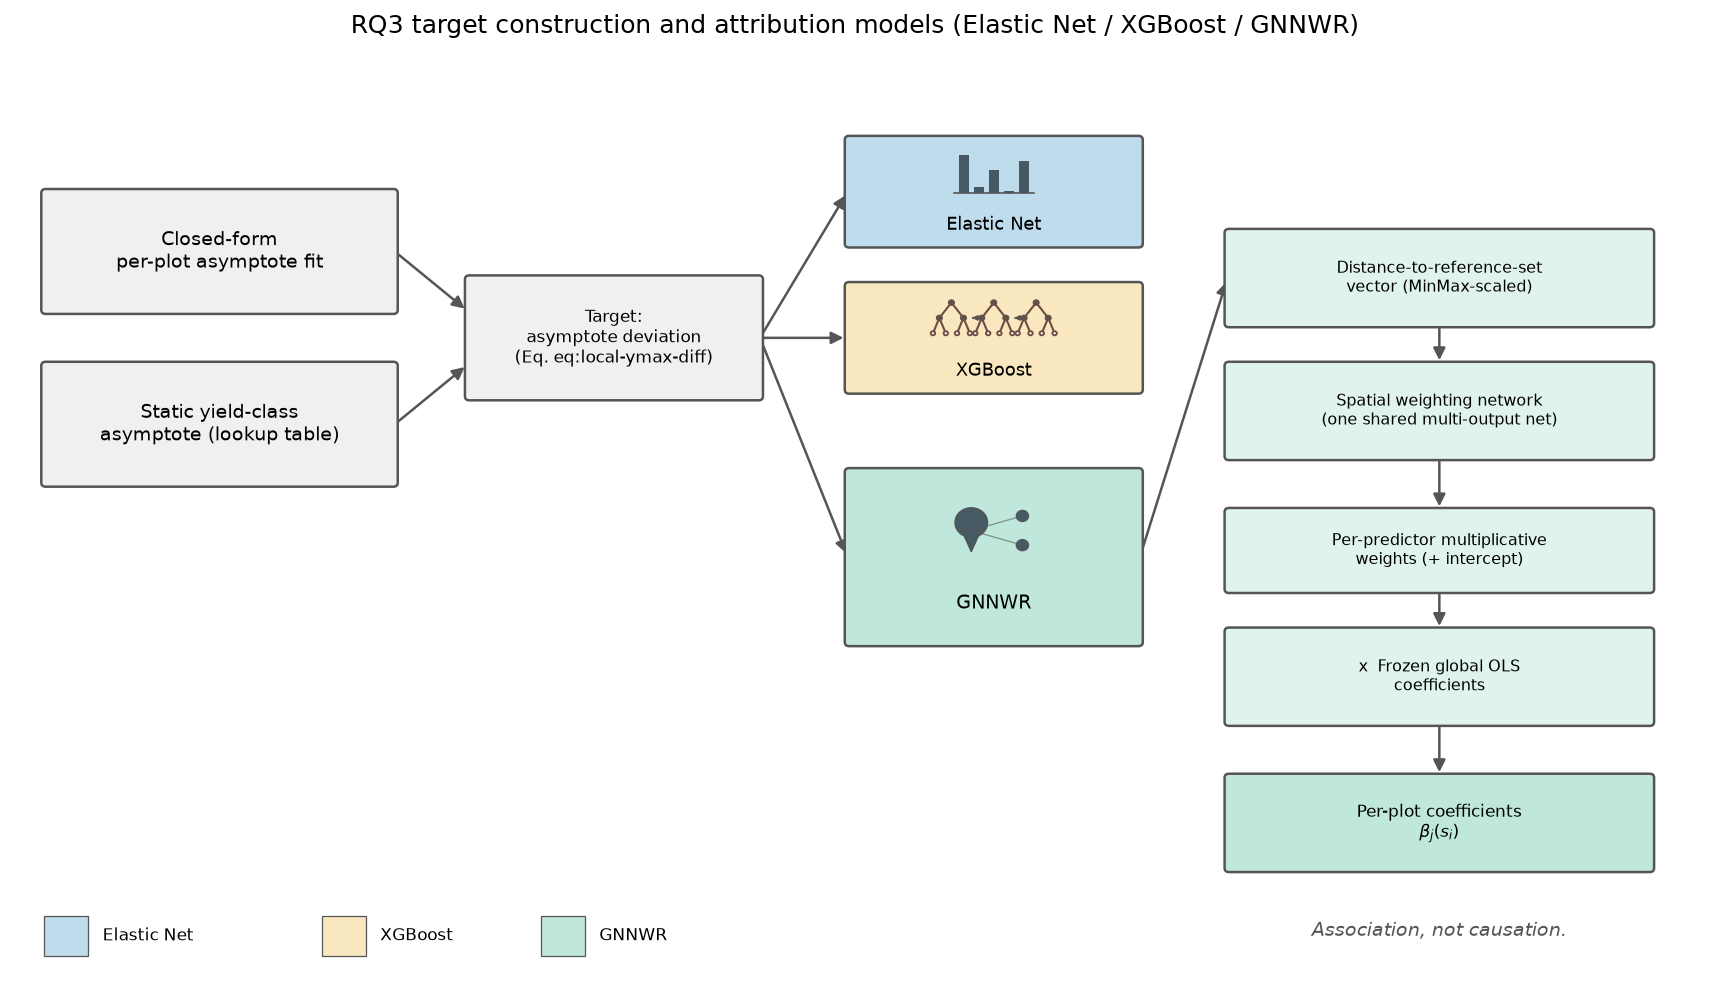

In [15]:
# Colour distinguishes which ATTRIBUTION MODEL each box belongs to. GNNWR's colour is
# carried through into its own internal-mechanism boxes on the right (as a lighter tint), so
# that expanded detail still visibly "belongs to" the GNNWR path rather than looking like a
# separate, disconnected diagram. Target-construction boxes (left) feed all three models
# equally, so they stay neutral grey rather than being tied to any one model's colour.
MODEL_COLOR_EN = lighten_color(COLOR_TRAIN, 0.75)
MODEL_COLOR_XGB = lighten_color(COLOR_VAL, 0.75)
MODEL_COLOR_GNNWR = lighten_color(COLOR_TEST, 0.75)
MODEL_COLOR_GNNWR_DETAIL = lighten_color(COLOR_TEST, 0.88)  # lighter still, for the expanded mechanism boxes

fig, ax = new_schematic_axes(figsize=(11.5, 6.8), xlim=(0, 11.5), ylim=(-0.6, 6.5))

# --- Target construction (left, neutral -- feeds all three models equally) ---
draw_box_v2(ax, 0.2, 4.5, 2.4, 0.9, "Closed-form\nper-plot asymptote fit", facecolor=COLOR_NEUTRAL_BOX)
draw_box_v2(ax, 0.2, 3.2, 2.4, 0.9, "Static yield-class\nasymptote (lookup table)", facecolor=COLOR_NEUTRAL_BOX)
draw_box_v2(ax, 3.1, 3.85, 2.0, 0.9, "Target:\nasymptote deviation\n(Eq. eq:local-ymax-diff)", facecolor=COLOR_NEUTRAL_BOX, fontsize=8)

draw_arrow_v2(ax, (2.6, 4.95), (3.1, 4.5))
draw_arrow_v2(ax, (2.6, 3.65), (3.1, 4.1))

# --- Three attribution models, icon above name ---
draw_box_v2(ax, 5.7, 5.0, 2.0, 0.8, "", facecolor=MODEL_COLOR_EN)
draw_elastic_net_icon(ax, 6.7, 5.55, 0.55, 0.32, "#455A64")
ax.text(6.7, 5.15, "Elastic Net", ha="center", va="center", fontsize=8.5, zorder=4)

draw_box_v2(ax, 5.7, 3.9, 2.0, 0.8, "", facecolor=MODEL_COLOR_XGB)
draw_xgboost_icon(ax, 6.7, 4.45, 0.5, "#6D4C41")
ax.text(6.7, 4.05, "XGBoost", ha="center", va="center", fontsize=8.5, zorder=4)

draw_box_v2(ax, 5.7, 2.0, 2.0, 1.3, "", facecolor=MODEL_COLOR_GNNWR)
draw_gnnwr_icon(ax, 6.7, 2.85, 0.7, 0.5, "#455A64")
ax.text(6.7, 2.3, "GNNWR", ha="center", va="center", fontsize=9, zorder=4)

draw_arrow_v2(ax, (5.1, 4.3), (5.7, 5.4))
draw_arrow_v2(ax, (5.1, 4.3), (5.7, 4.3))
draw_arrow_v2(ax, (5.1, 4.3), (5.7, 2.65))

# --- GNNWR internal mechanism (expanded box on the right, tinted with GNNWR's own colour) ---
draw_box_v2(ax, 8.3, 4.4, 2.9, 0.7, "Distance-to-reference-set\nvector (MinMax-scaled)", facecolor=MODEL_COLOR_GNNWR_DETAIL, fontsize=7.5)
draw_box_v2(ax, 8.3, 3.4, 2.9, 0.7, "Spatial weighting network\n(one shared multi-output net)", facecolor=MODEL_COLOR_GNNWR_DETAIL, fontsize=7.5)
draw_box_v2(ax, 8.3, 2.4, 2.9, 0.6, "Per-predictor multiplicative\nweights (+ intercept)", facecolor=MODEL_COLOR_GNNWR_DETAIL, fontsize=7.5)
draw_box_v2(ax, 8.3, 1.4, 2.9, 0.7, "x  Frozen global OLS\ncoefficients", facecolor=MODEL_COLOR_GNNWR_DETAIL, fontsize=7.5)
draw_box_v2(ax, 8.3, 0.3, 2.9, 0.7, "Per-plot coefficients\n$\\beta_j(s_i)$", facecolor=MODEL_COLOR_GNNWR, fontsize=8)

draw_arrow_v2(ax, (7.7, 2.65), (8.3, 4.75))
draw_arrow_v2(ax, (9.75, 4.4), (9.75, 4.1))
draw_arrow_v2(ax, (9.75, 3.4), (9.75, 3.0))
draw_arrow_v2(ax, (9.75, 2.4), (9.75, 2.1))
draw_arrow_v2(ax, (9.75, 1.4), (9.75, 1.0))

# --- Colour key ---
key_items = [(MODEL_COLOR_EN, "Elastic Net"), (MODEL_COLOR_XGB, "XGBoost"), (MODEL_COLOR_GNNWR, "GNNWR")]
key_x = 0.2
for color, label in key_items:
    swatch = Rectangle((key_x, -0.35), 0.3, 0.3, facecolor=color, edgecolor=COLOR_NEUTRAL_EDGE, linewidth=0.6)
    ax.add_patch(swatch)
    ax.text(key_x + 0.4, -0.2, label, fontsize=8, va="center")
    key_x += 0.4 + len(label) * 0.1 + 0.4

ax.text(9.75, -0.2, "Association, not causation.", fontsize=9, style="italic", color=COLOR_NEUTRAL_EDGE, ha="center")

ax.set_title("RQ3 target construction and attribution models (Elastic Net / XGBoost / GNNWR)", fontsize=12)
plt.tight_layout()
plt.show()

## Summary

Nothing is saved to disk yet -- every figure above is display-only while we iterate on layout
and styling. Once a figure is finalised, save it explicitly from its own cell, e.g.:

```python
plt.savefig(FIGURES_DIR / "age_linearity.png")
```

Each `FIGURE PLACEHOLDER` box in the `.tex` source can then be replaced with
`\includegraphics[width=0.9\textwidth]{4_Chapter_methodology/figures/<name>.png}` pointing at the
saved file. The three schematic diagrams (pipeline overview, model architecture, RQ3 mechanism) are
a first pass built directly from the chapter's own caption/spec text and still need visual polish
(colour usage, left-to-right flow) before they are ready to save.